In [3]:
# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
import pickle

In [4]:
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm
L_jup = 3.846e30  # erg/s

# Physical constants
M_sun = 1.989e33 
M_jup = 1.898e30
R_jup = 7.149e9
#AU = 1.496e13
sec_per_yr = 3.156e7
Rgas = 8.314e7  # erg/(mol K)


# Luminosity

Rp vs Mp Data:
  Mp range: 0.0160 to 10.3211 M_Jup
  Rp range: 0.6952 to 2.3048 R_Jup


Rp vs Mp Data:
  Mp range: 0.0160 to 10.3211 M_Jup
  Rp range: 0.6952 to 2.3048 R_Jup


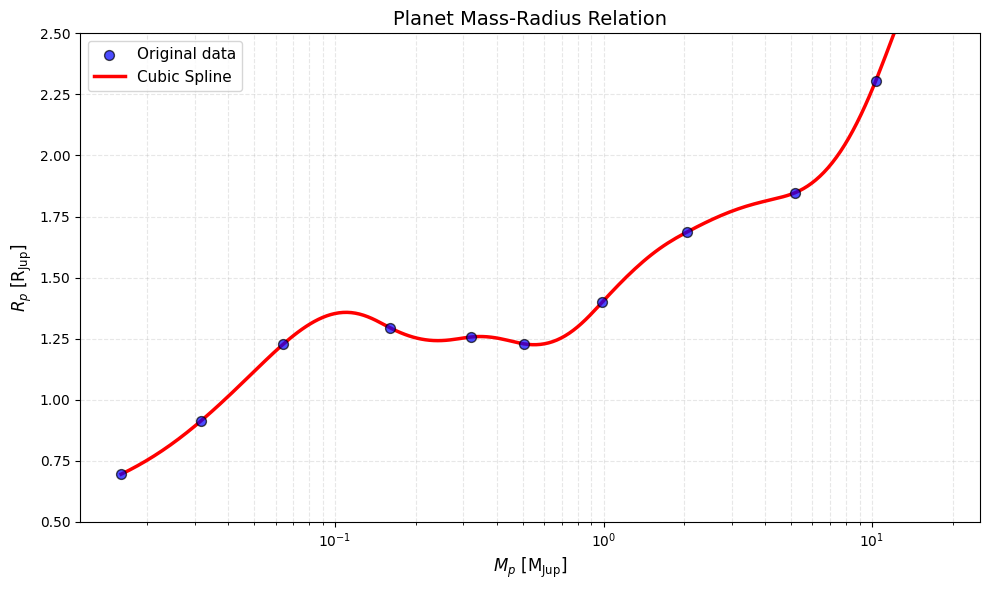

Rp vs Mp Data:
  Mp range: 0.0160 to 10.3211 M_Jup
  Rp range: 0.6952 to 2.3048 R_Jup


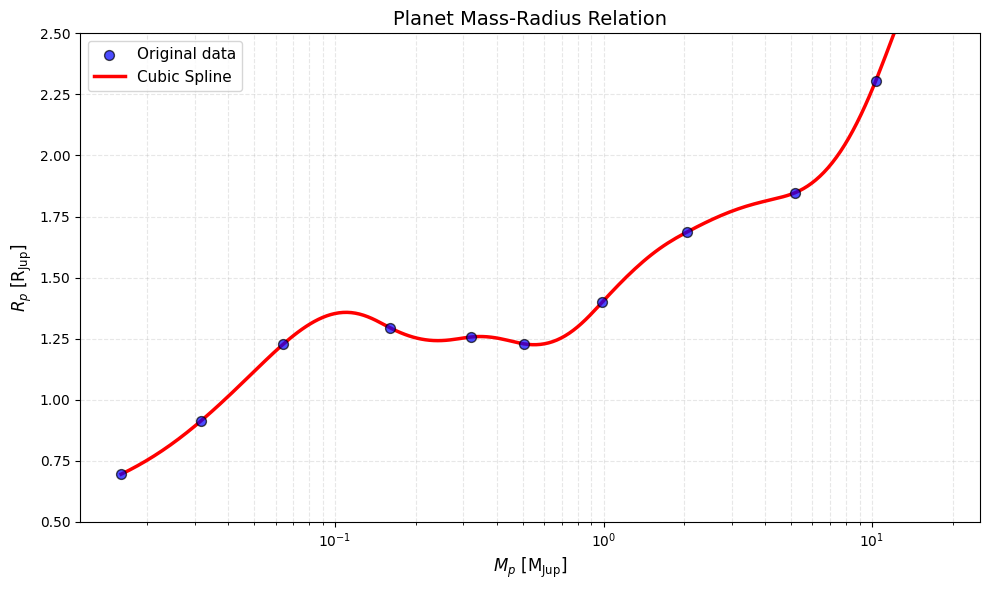

✅ Rp_from_Mp function created!
   Example: Rp_from_Mp(1.0) = 1.405 R_Jup
   Example: Rp_from_Mp(5.0) = 1.841 R_Jup

Lp vs Mp Data:
  Mp range: 0.0158 to 9.8432 M_Jup
  Lp range: 4.88e-09 to 1.64e-03 L_sun


Rp vs Mp Data:
  Mp range: 0.0160 to 10.3211 M_Jup
  Rp range: 0.6952 to 2.3048 R_Jup


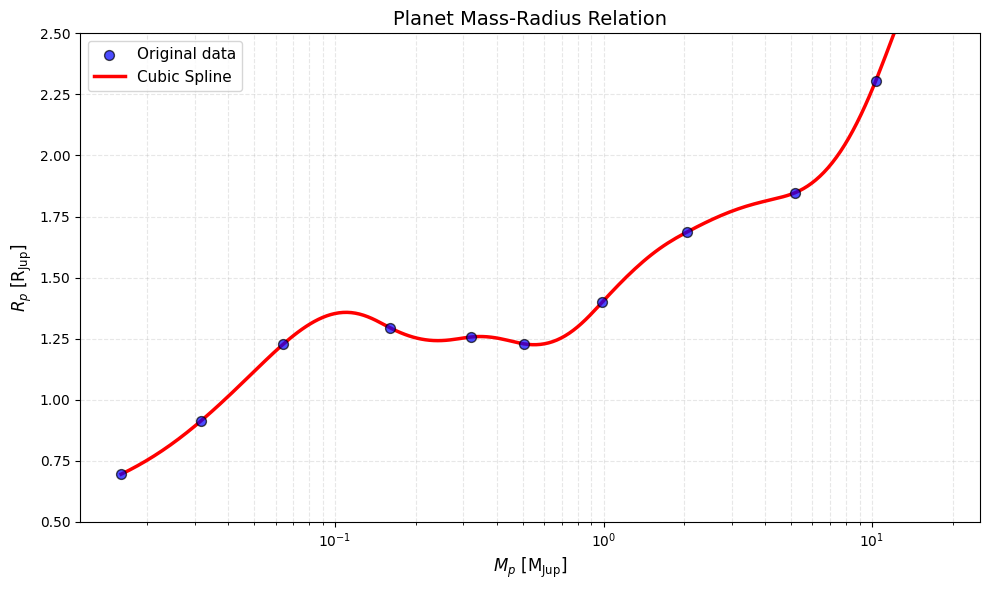

✅ Rp_from_Mp function created!
   Example: Rp_from_Mp(1.0) = 1.405 R_Jup
   Example: Rp_from_Mp(5.0) = 1.841 R_Jup

Lp vs Mp Data:
  Mp range: 0.0158 to 9.8432 M_Jup
  Lp range: 4.88e-09 to 1.64e-03 L_sun


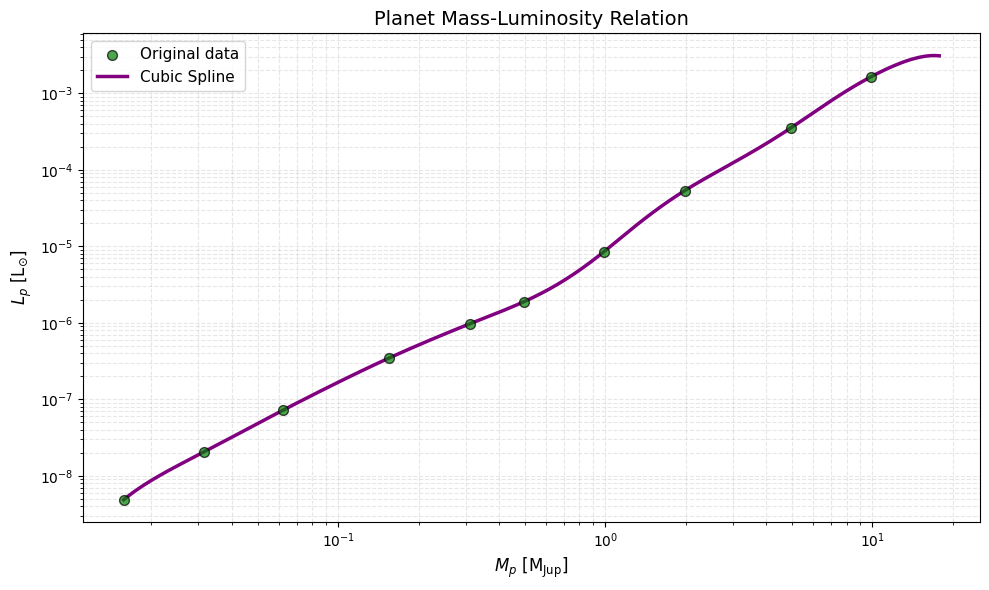

✅ Lp_from_Mp function created!
   Example: Lp_from_Mp(1.0) = 8.79e-06 L_sun
   Example: Lp_from_Mp(5.0) = 3.61e-04 L_sun
Lp_from_Mp spline saved to d:/CPD_MPIA/utils/Lp_from_Mp.pkl
Rp_from_Mp spline saved to d:/CPD_MPIA/utils/Rp_from_Mp.pkl


In [5]:
# Load CSV files
import pandas as pd
from scipy.interpolate import CubicSpline
import os

# Load Rp vs Mp data
csv_path_RpMp = os.path.join('..', 'RpMpAndrewstrial1.csv')
RpMp_data = pd.read_csv(csv_path_RpMp, header=None, skipinitialspace=True)

# Load Lp vs Mp data
csv_path_LpMp = os.path.join('..', 'LpMpAndrews.csv')
LpMp_data = pd.read_csv(csv_path_LpMp, header=None, skipinitialspace=True)

# ============================================
# 1. Rp vs Mp Interpolation
# ============================================

# Extract and sort Rp-Mp data
Mp_RpData = RpMp_data[0].values  # Planet mass [M_Jup]
Rp_data = RpMp_data[1].values    # Planet radius [R_Jup]

sort_idx_Rp = np.argsort(Mp_RpData)
Mp_RpData_sorted = Mp_RpData[sort_idx_Rp]
Rp_data_sorted = Rp_data[sort_idx_Rp]

print("=" * 50)
print("Rp vs Mp Data:")
print(f"  Mp range: {Mp_RpData_sorted.min():.4f} to {Mp_RpData_sorted.max():.4f} M_Jup")
print(f"  Rp range: {Rp_data_sorted.min():.4f} to {Rp_data_sorted.max():.4f} R_Jup")
print("=" * 50)

# Create interpolation grid
Mp_grid_Rp = np.logspace(np.log10(Mp_RpData_sorted.min()), 
                          1.25, 200)

# Cubic spline interpolation
Rp_spline = CubicSpline(Mp_RpData_sorted, Rp_data_sorted, bc_type='natural')
Rp_interpolated = Rp_spline(Mp_grid_Rp)

# Plot Rp vs Mp
plt.figure(figsize=(10, 6))
plt.scatter(Mp_RpData, Rp_data, label='Original data', color='blue', 
            s=50, alpha=0.7, edgecolors='black', zorder=3)
plt.plot(Mp_grid_Rp, Rp_interpolated, label='Cubic Spline', 
         linestyle='-', linewidth=2.5, color='red')
plt.xlabel(r'$M_p$ [M$_{\rm Jup}$]', fontsize=12)
plt.ylabel(r'$R_p$ [R$_{\rm Jup}$]', fontsize=12)
plt.title('Planet Mass-Radius Relation', fontsize=14)
plt.xscale('log')
plt.ylim(0.5, 2.5)  # Limit y-axis range
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.tight_layout()
plt.show()

# Create reusable function
Rp_from_Mp = CubicSpline(Mp_RpData_sorted, Rp_data_sorted, 
                         bc_type='natural', extrapolate=True)

print(f"✅ Rp_from_Mp function created!")
print(f"   Example: Rp_from_Mp(1.0) = {Rp_from_Mp(1.0):.3f} R_Jup")
print(f"   Example: Rp_from_Mp(5.0) = {Rp_from_Mp(5.0):.3f} R_Jup\n")

# ============================================
# 2. Lp vs Mp Interpolation
# ============================================

# Extract and sort Lp-Mp data
Mp_LpData = LpMp_data[0].values  # Planet mass [M_Jup]
Lp_data = LpMp_data[1].values    # Planet luminosity [L_sun]

sort_idx_Lp = np.argsort(Mp_LpData)
Mp_LpData_sorted = Mp_LpData[sort_idx_Lp]
Lp_data_sorted = Lp_data[sort_idx_Lp]

print("=" * 50)
print("Lp vs Mp Data:")
print(f"  Mp range: {Mp_LpData_sorted.min():.4f} to {Mp_LpData_sorted.max():.4f} M_Jup")
print(f"  Lp range: {Lp_data_sorted.min():.2e} to {Lp_data_sorted.max():.2e} L_sun")
print("=" * 50)

# Create interpolation grid
Mp_grid_Lp = np.logspace(np.log10(Mp_LpData_sorted.min()), 
                          1.25, 200)

# Cubic spline interpolation
Lp_spline = CubicSpline(Mp_LpData_sorted, Lp_data_sorted, bc_type='natural')
Lp_interpolated = Lp_spline(Mp_grid_Lp)

# Plot Lp vs Mp
plt.figure(figsize=(10, 6))
plt.scatter(Mp_LpData, Lp_data, label='Original data', color='green', 
            s=50, alpha=0.7, edgecolors='black', zorder=3)
plt.plot(Mp_grid_Lp, Lp_interpolated, label='Cubic Spline', 
         linestyle='-', linewidth=2.5, color='purple')
plt.xlabel(r'$M_p$ [M$_{\rm Jup}$]', fontsize=12)
plt.ylabel(r'$L_p$ [L$_{\odot}$]', fontsize=12)
plt.title('Planet Mass-Luminosity Relation', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.tight_layout()
plt.show()

# Create reusable function
Lp_from_Mp = CubicSpline(Mp_LpData_sorted, Lp_data_sorted, 
                         bc_type='natural', extrapolate=True)

print(f"✅ Lp_from_Mp function created!")
print(f"   Example: Lp_from_Mp(1.0) = {Lp_from_Mp(1.0):.2e} L_sun")
print(f"   Example: Lp_from_Mp(5.0) = {Lp_from_Mp(5.0):.2e} L_sun")
print("=" * 50)

import os

os.makedirs('d:/CPD_MPIA/utils/', exist_ok=True)  # Create folder if missing
from joblib import dump

# Save the CubicSpline object to disk
dump(Lp_from_Mp, 'd:/CPD_MPIA/utils/Lp_from_Mp.pkl')
print("Lp_from_Mp spline saved to d:/CPD_MPIA/utils/Lp_from_Mp.pkl")
dump(Rp_from_Mp, 'd:/CPD_MPIA/utils/Rp_from_Mp.pkl')
print("Rp_from_Mp spline saved to d:/CPD_MPIA/utils/Rp_from_Mp.pkl")

# Model Function



In [6]:
def B_nu(nu, T):
    """
    Planck function in frequency (erg s^-1 cm^-2 Hz^-1 sr^-1)
    nu: frequency in Hz
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    
    return (2*h*nu**3 / c**2) / (np.exp(h*nu/(k*T)) - 1)

def calculate_disk_properties_Andrews(M_star = 1, Mp = 1, Mdot = 1.56, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 22, d_pc = 167, 
                             lam_nu=240 , 
                             Lstar = 1.0 , show_results = False, Rout=None, M_cpd = 0.01, inc = 16 , add_T = None):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    M_star : float
        Stellar mass (M_sun)
    lam_nu : float
        Frequency (GHz)
    Mp : float
        Planet mass (M_jup)
    Mdot : float  
        Accretion rate (M_jup/Myr)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (Rjup)
    Rp : float
        distance of planet from star (au)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet"
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (L_sun)
    

    Lstar : float
        Stellar luminosity (L_sun)
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    # Turn input values to cgs
    # Disk parameters
    M_star = M_star * M_sun
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / (sec_per_yr*1e6)
    Rin = Rin * R_jup
    rp = rp * AU # planet orbital radius in cm
    Rp = Rp_from_Mp(Mp / M_jup)*R_jup  # planet radius in cm

    # Turn the luminosites to erg/s
    Lstar = Lstar * L_sun
    
    # 1. Create radial grid between Rin and Rout

    

    if Rout is None:
        Rout = (1/3) * rp * (Mp / (3 * M_star))**(1/3)
    else:
        Rout = Rout * AU  # assume input Rout is in AU


    R = np.geomspace(Rp*1.01, Rout, 100)  # cm
    
    # 2. Calculate T(R)
    # Accretion irradiation
    
    T_irr = (3*G * Mp * Mdot / (8*np.pi*sigmaB*R**3) * (1 - np.sqrt(Rp/R)))**(1/4)  # K # RJUP CAN BE WRONG  NEED PLANET RADIUS
    
    #print(f'L_irr = {L_irr/L_sun:.2e} L_sun')

    # Planet irradiation
    Lplanet = Lp_from_Mp(Mp / M_jup) * L_sun  # erg/s
    T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame

    # Star irradiation

    phi_flare = 0.02   # flaring angle of the host disk   (Huang et al. (2018b))

    T_irr_star = (phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2))**0.25  # K

    T_ext= (T_irr**4 + T_irr_p**4 + T_irr_star**4 )**0.25  # K
    

    if add_T is not None:
        T_ext = (T_ext**4 + add_T**4)**0.25
        
    
    #---------------------------------------
    # -------------SIGMA--------------------
    # --------------------------------------
    
    gamma = 0.75
    M_cpd = M_cpd * M_jup  # CPD mass in grams


    Sigma0 = (2 - gamma) * M_cpd /  (2 * np.pi * Rout**gamma) * (Rout**(2 - gamma) - Rp**(2 - gamma))**(-1)
    Sigma = Sigma0 * (R/Rout)**(-gamma)




    #---------------------------------------
    #---------------Flux--------------------
    # --------------------------------------
      
 

    kappa_nu = 3.5*(lam_nu/345)  #cm^2/g

    tau_nu = kappa_nu * Sigma

    # Assume face-on disk: mu = cos(i) = 1

    # turn inc from degree to radian

    mu = np.cos(np.radians(inc))# i is the inclination angle in degree in table 2

    # Convert distance to cm
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm

    # Integrand: B_nu(T) * (1 - exp(-tau/mu)) * r
    # Ignoring omega_nu (scattering) term as specified
    integrand = B_nu(lam_nu * 1e9, T_ext) * (1 - np.exp(-tau_nu / mu)) * R

    # Integrate using trapezoidal rule
    flux_integral = np.trapz(integrand, R)

    # Total observed flux at Earth
    F_cpd = (2 * np.pi * mu / d_cm**2) * flux_integral  # erg s^-1 cm^-2 Hz^-1

    # Convert to microJy
    F_microJy = F_cpd / 1e-29  # µJy

    
    return {
        'R': R,
        'Rout': Rout / AU,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Sigma': Sigma,
        'tau_nu_max': np.max(tau_nu),
        'F_nu_tot': F_microJy,
        'M_cpd': M_cpd / M_jup,
        'T_irr': T_irr,
        'T_irr_p': T_irr_p,
        'T_irr_star': T_irr_star
    }




# Check model consistency with Andrews HD143006

Measure the flux limit at the innergap of the disk and try to obtain the same planet properties. Relevant to table 3 and table 4  - try to reproduce table 4.
since the observation is made in different wavelengths, I will take the flux he measured at the wavelength and the location of the gap, plug into my model to plot the radius versus planet mass for D22 and D51 gap. 

1. Change the gap location unit from mas to au (au = mas *dc/1000)
2. Makesure flux is in value of microJy (take the range of flux values for each recovery fraction to verify as it would make it more convenient for me if I want to do CPD injection recovery too) 
3. Plot them


*Note: the observing frequency is 240 GHz which is 1.25 mm , the wavelength-dependent opacity is 2.4 cm^2/g*


Okay , so the situation now is that , the contour levels should be changed into recovery fractions (if present) or sigma levels , the one overlaying line should be the ALMA angular resolution,  representing the locus of CPD parameters where the CPD angular size equals the beam: theta_cpd = Rcpd/d = theta_ALMA, therefore y axis (Rcpd/RHill) = theta_beam*d/RHill , where RHill depends on Mp. so thats the contour line that shows below which the CPD is unresolved. 
without the recovery fractions...what is the minimum flux? should I keep the whole recovery fraction relevant relation as an if case? 




In [7]:
def compute_flux_map(
    target_flux_arr,
    disk_arr,
    rp=165,
    alpha=1e-3,
    y_max=0.8,
    y_min=0.05,
    m_max = 1.25,
    m_min = -2,
    mcpd_min = -5.5,
    mcpd_max = -3,
    lam_nu=240,
    inc=16,
    mode="default",
    overwrite=False,
    save=True,
    verbose=True,
    n_jobs= 4
):
    """
    Compute flux and CPD mass grids for given disk parameters.
    Optionally caches results in /Andrews folder.

    Returns:
        Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen
    """
    import os
    import numpy as np
    import pandas as pd

    # === Optional caching ===
    save_dir = "Andrews"
    os.makedirs(save_dir, exist_ok=True)
    fname = f"{disk_arr[0]}_{rp}_alpha{alpha}_{mode}.csv"
    save_path = os.path.join(save_dir, fname)

    if save and os.path.exists(save_path) and not overwrite:
        if verbose:
            print(f"Loading cached results from {save_path}")
        df = pd.read_csv(save_path)
        Mp_grid = df['Mp_grid'].unique()
        Rout_frac_grid = df['Rout_frac_grid'].unique()
        Flux_vals = df['Flux_vals'].values.reshape(len(Rout_frac_grid), len(Mp_grid))
        M_cpd_chosen = df['Mcpd_vals'].values.reshape(len(Rout_frac_grid), len(Mp_grid))
        return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

    # === Computation ===
    Mp_grid = np.logspace(m_min, m_max, 100)
    M_cpd_grid = np.logspace(mcpd_min, mcpd_max, 80)
    Rout_frac_grid = np.linspace(y_min, y_max, 80)
    M_star_jup = disk_arr[1] * 1047.56

    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_cpd_chosen = np.zeros_like(Flux_vals)

    # ================================================================
    # === 3. Define per-cell computation ==============================
    # ================================================================
    def compute_cell(i, j, frac, Mp):
        """Compute one (Rout/RH, Mp) grid cell."""
        try:
            # --- Hill radius & outer disk radius (in AU) ---
            RHill = rp * (Mp / (3 * M_star_jup)) ** (1/3)
            Rout = frac * RHill

            # --- Skip unphysical small disks ---
            Rp_planet = Rp_from_Mp(Mp)  # [Rjup]
            Rp_planet_AU = Rp_planet * R_jup / AU
            if Rout <= Rp_planet_AU:
                return (i, j, 0.0, 0.0)

            # --- Iterate through CPD masses until flux threshold reached ---
            for M_cpd in M_cpd_grid:
                out = calculate_disk_properties_Andrews(
                    M_star=disk_arr[1], Mp=Mp, alpha=alpha,
                    Rin=1, rp=rp, d_pc=disk_arr[2],
                     Lstar=disk_arr[3],
                    Rout=Rout, M_cpd=M_cpd, inc=inc, lam_nu=lam_nu
                )
                flux = out["F_nu_tot"]
                M_cpd = out["M_cpd"]
                

                # Stop at first mass exceeding detection threshold
                if flux >= target_flux_arr[0]:
                    if verbose and (i % 10 == 0 and j % 20 == 0):
                        print(f"[{i:02d},{j:02d}] Rout/RH={frac:.3f}, Mp={Mp:.3f} -> Fν={Flux_vals[i,j]:.2f} µJy")

                    return (i, j, flux, M_cpd)


                # No detection: return zeros
            return (i, j, 0.0, 0.0)
        
        
        except Exception as e:
            if verbose:
                print(f"[WARN] Cell (i={i}, j={j}) failed: {e}")
            return (i, j, 0.0, 0.0)


    # ================================================================
    # === 4. Run parallel computation ================================
    # ================================================================
    results = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(compute_cell)(i, j, frac, Mp)
        for i, frac in enumerate(Rout_frac_grid)
        for j, Mp in enumerate(Mp_grid)
    )

    # ================================================================
    # === 5. Collect and reshape results ==============================
    # ================================================================
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_cpd_chosen = np.zeros_like(Flux_vals)

    for i, j, flux, M_cpd in results:
        Flux_vals[i, j] = flux
        M_cpd_chosen[i, j] = M_cpd

    # ================================================================
    # === 6. Summary and diagnostics =================================
    # ================================================================
    if verbose:
        n_nonzero = np.sum(Flux_vals > 0)
        print(f"[INFO] Non-zero flux points: {n_nonzero}/{Flux_vals.size}")
        if n_nonzero == 0:
            print("[WARN] All fluxes are zero — check units or disk model scaling.")

    # === Save ===
    if save:
        df = pd.DataFrame({
            'Mp_grid': np.tile(Mp_grid, len(Rout_frac_grid)),
            'Rout_frac_grid': np.repeat(Rout_frac_grid, len(Mp_grid)),
            'Flux_vals': Flux_vals.flatten(),
            'Mcpd_vals': M_cpd_chosen.flatten()
        })
        df.to_csv(save_path, index=False)
        if verbose:
            print(f"Saved results to {save_path}")

    return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

def plot_flux_map(Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
                  disk_arr, rp=165, alpha=1e-3, res_au = 7.4 , plotmass=True,
                  color='Blues', y_max=0.8, y_min=0.05, sigma_ujy=None, det_sigma=None, min = -5.5, max = -3.2):
    """
    Plot precomputed flux or CPD-mass maps with flexible styling.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(7, 5))

    if plotmass:
        
        levels = np.arange(min, max, 0.2)
        cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),
                         levels=levels, cmap=color)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$', fontsize=11)
    else:
        cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
                         levels=7, cmap=color)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    # Add ALMA beam limit
    M_star_jup = disk_arr[1] * 1047.56
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    #Rout_frac_beam = 7.4/ (2 * RHill_arr) # Jane Huang 2018 table 2
    # res_au = theta_beam*d_pc 
    Rout_frac_beam = res_au/(2 * RHill_arr) # Updated beam limit calculation
    ax.plot(np.log10(Mp_grid), Rout_frac_beam, color='red', lw=2, label='detection limit')

    # plot the 3,5, sigma lines
    # plot the detection sigma line if present 

    if sigma_ujy is not None:
    # Plot 3σ and 5σ lines (same style)
        for level, label in zip([3 * sigma_ujy, 5 * sigma_ujy], ['3σ', '5σ']):
            Rout_frac_sigma = []
            for j, Mp in enumerate(Mp_grid):
                above = np.where(Flux_vals[:, j] >= level)[0]
                Rout_frac_sigma.append(Rout_frac_grid[above[0]] if len(above) > 0 else np.nan)
            ax.plot(np.log10(Mp_grid), Rout_frac_sigma, linestyle='--', color='black', label=label)
        # Plot detected sigma line if present, with different style
        if det_sigma is not None:
            level = sigma_ujy * det_sigma
            label = f'{det_sigma:.2f}σ'
            Rout_frac_sigma = []
            for j, Mp in enumerate(Mp_grid):
                above = np.where(Flux_vals[:, j] >= level)[0]
                Rout_frac_sigma.append(Rout_frac_grid[above[0]] if len(above) > 0 else np.nan)
            ax.plot(np.log10(Mp_grid), Rout_frac_sigma, linestyle='-.', color='tab:blue', linewidth=2, label=label)

    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(y_min, y_max)
    ax.legend()

    ax.set_title(f"{disk_arr[0]} at $r_p$={rp:.1f} AU, α={alpha}")
    plt.tight_layout()
    plt.show()

In [8]:
# Gap of HD143006 from Andrews paper
# D22:  103 (mas for r_peak), 
# D51  : 338 (mas for r_peak),

HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8]

D22_target_flux_arr = [71, 79, 88, 97, 111, 220]  # mu Jy for different recovery fractions from 0.5 to 1.0

D51_target_flux_arr = [85, 92, 98, 107, 120, 185]  # mu Jy for different recovery fractions from 0.5 to 1.0
rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

Mp_D22, Rout_D22, Flux_D22, Mcpd_D22 = compute_flux_map(
    target_flux_arr=D22_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-3,
    lam_nu=240,
    overwrite=False
)

Mp_D51, Rout_D51, Flux_D51, Mcpd_D51 = compute_flux_map(
    target_flux_arr=D51_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    alpha=1e-3,
    lam_nu=240,
    overwrite=False
)

Loading cached results from Andrews\HD143006_22_alpha0.001_default.csv
Loading cached results from Andrews\HD143006_51_alpha0.001_default.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


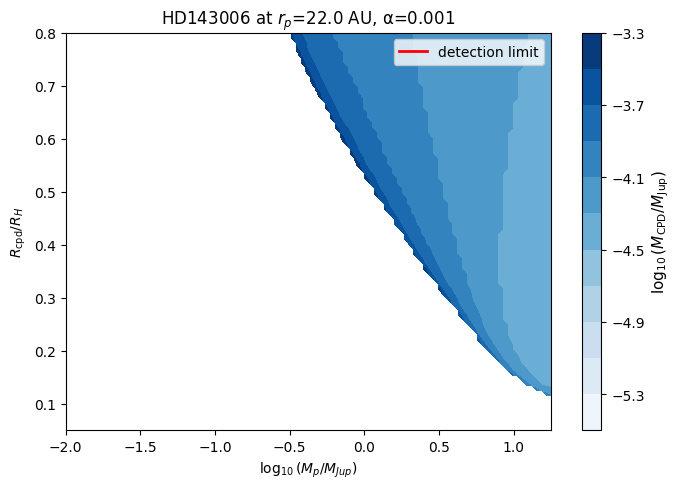

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


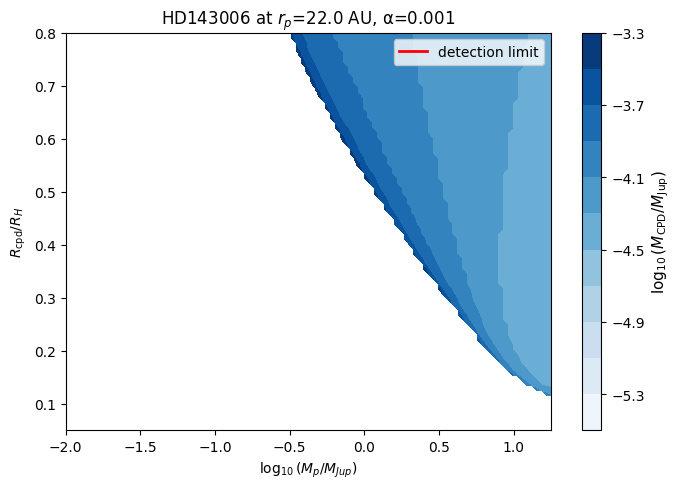

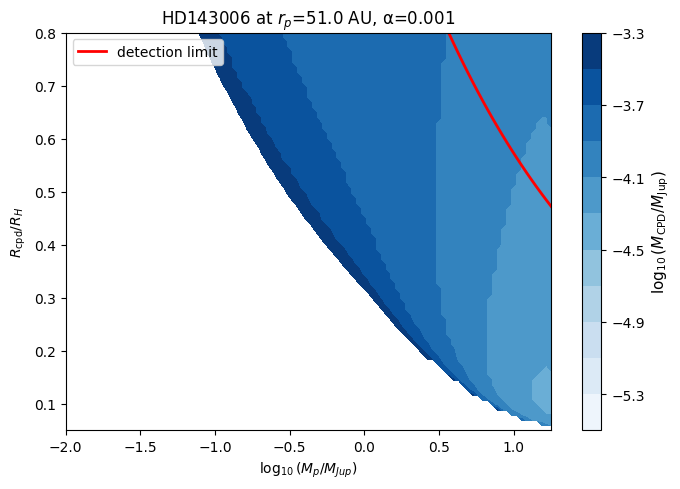

In [9]:
# D22 gap



plot_flux_map(
    Mp_D22, Rout_D22, Flux_D22, Mcpd_D22,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=7.4

)

# D51 gap
plot_flux_map(
    Mp_D51, Rout_D51, Flux_D51, Mcpd_D51,
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=7.4
)

In [10]:
print(80*60*100)

480000


# Extend the method to exoALMA targets

In [11]:
# Extend it to ALMA disks
 # name, Mstar (Msun), d_pc, Lstar (Lsun), Fnu (muJy), inc (deg)
disk_arr = {
    "AA_Tau":      ["AA_Tau", 0.79, 145, 1.1, 0.12, 58.54, "04 34 55.420", "+24 28 53.034"],
    "CQ_Tau":      ["CQ_Tau", 1.4, 149, 10, 0.135, 35.24, "05 35 58.467", "+24 44 54.091"],
    "DM_Tau":      ["DM_Tau", 0.45, 144, 0.24, 0.134, 35.97, "04 33 48.733", "+18 10 09.973"],
    "HD_34282":    ["HD_34282", 1.61, 309, 108, 0.106, 59.09, "05 16 00.477", "-09 48 35.394"],
    "HD_135344B":  ["HD_135344B", 1.61, 135, 6.7, 0.26, 20.73, "15 15 48.446", "-37 09 16.024"],
    "HD_143006":   ["HD_143006", 1.56, 167, 3.8, 0.226, 18.69, "15 58 36.913", "-22 57 15.221"],
    "J1604":       ["J1604", 1.29, 112, 0.76, 0.257, 8.72, "16 04 21.642", "-21 30 29.058"],
    "J1615":       ["J1615", 1.14, 156, 1.07, 0.303, 47.10, "16 15 20.234", "-32 55 05.099"],
    "J1842":       ["J1842", 1.07, 151, 0.8, 0.235, 39.22, "18 42 57.981", "-35 32 42.827"],
    "J1852":       ["J1852", 1.03, 147, 0.6, 0.236, 32.50, "18 52 17.301", "-37 00 11.949"],
    "LkCa_15":     ["LkCa_15", 1.14, 156, 1, 0.131, 50.59, "04 39 17.791", "+22 21 03.390"],
    "MWC_758":     ["MWC_758", 1.4, 151, 10.4, 0.241, 7.27, "05 30 27.529", "+25 19 57.076"],
    "PDS_66":      ["PDS_66", 1.28, 98, 1.2, 0.234, 32.02, "13 22 07.542", "-69 38 12.219"],
    "SY_Cha":      ["SY_Cha", 0.77, 182, 0.55, 0.178, 51.65, "10 56 30.388", "-77 11 39.402"],
    "V4046_Sgr":   ["V4046_Sgr", 1.73, 72, 0.5, 0.241, 33.36, "18 14 10.482", "-32 47 34.517"],
}

In [12]:
with open("disk_arr.pkl", "wb") as f:
    pickle.dump(disk_arr, f)

In [13]:



five_sigma_sources = [
    # Format: [disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB , detection sigma]
    ["CQ_Tau", 165.37, 260.30, 45.81 , 0.99, 5.08],
    ["CQ_Tau", 932.14, 1455, 40.25,0.76, 5.46],
    ["DM_Tau", 1845.47, 5422.67, 161.82, 0.36, 9.46 ],
    ["V4046_Sgr", 837.63, 90.54,22.22, 0.42, 5.24],
]


# Planet kink 

kink_sources = [
    # Format: [disk_name, radius_au, sigma_flux]
    ["AA_Tau", 80, 136.85],
    ["SY_Cha", 140, 57.23],
    ["J1842", 105, 35.29],
    ["J1615", 310, 24.56],
    ["LkCa_15", 240, 20.14],
    ["HD_143006", 32, 896.96],
]
    

In [14]:
for disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB,detection_sigma in five_sigma_sources:
    compute_flux_map(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        mode ="5sigma",
        overwrite=False
    )


# need change all the Andrew specific lie wavelength and detection limits


Loading cached results from Andrews\CQ_Tau_165.37_alpha0.001_5sigma.csv
Loading cached results from Andrews\CQ_Tau_932.14_alpha0.001_5sigma.csv
Loading cached results from Andrews\DM_Tau_1845.47_alpha0.001_5sigma.csv
Loading cached results from Andrews\V4046_Sgr_837.63_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


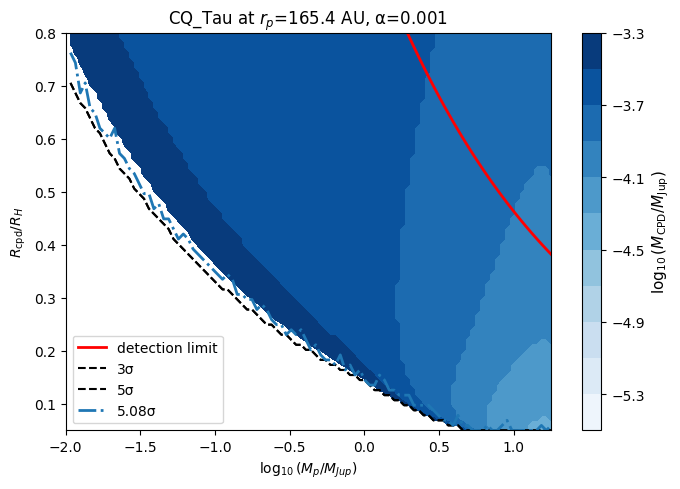

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


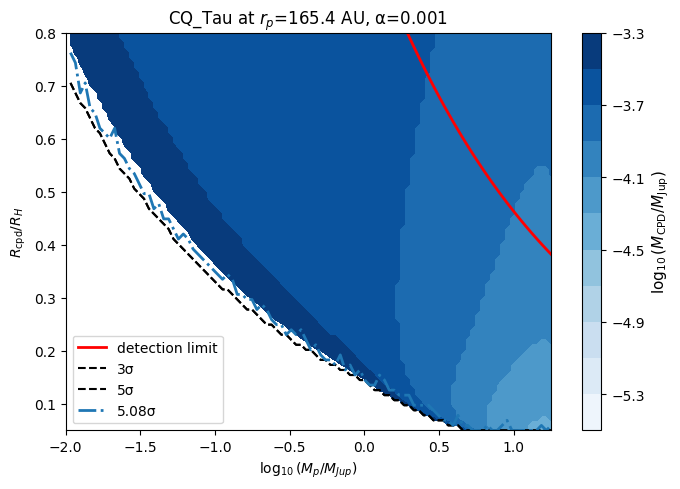

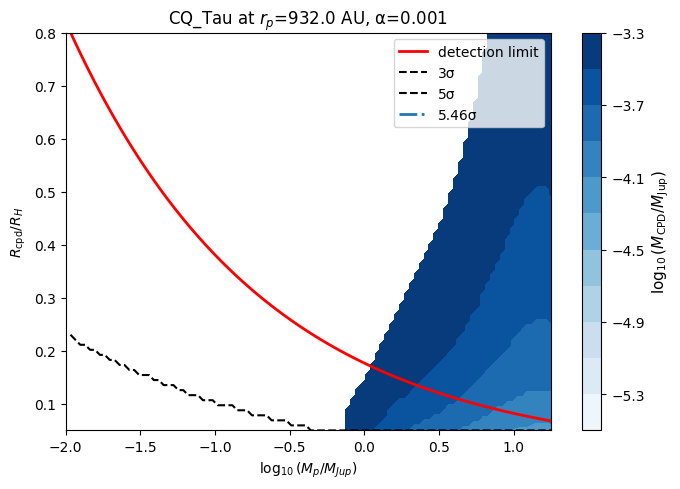

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


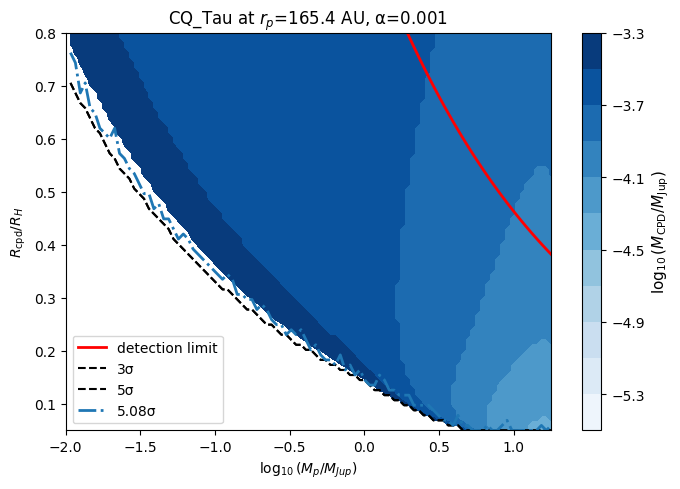

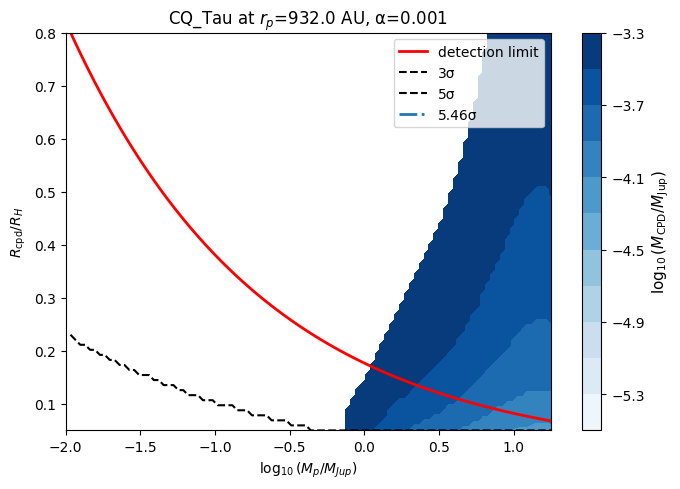

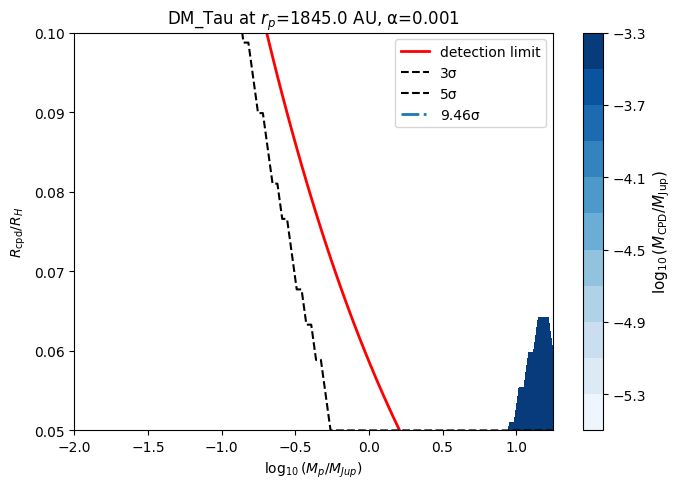

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


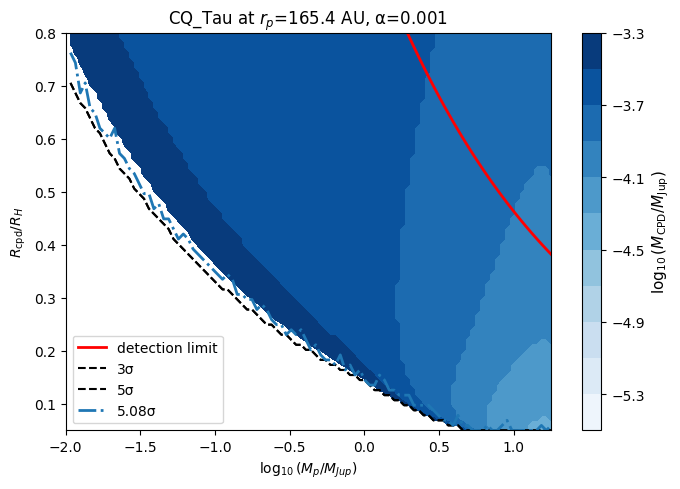

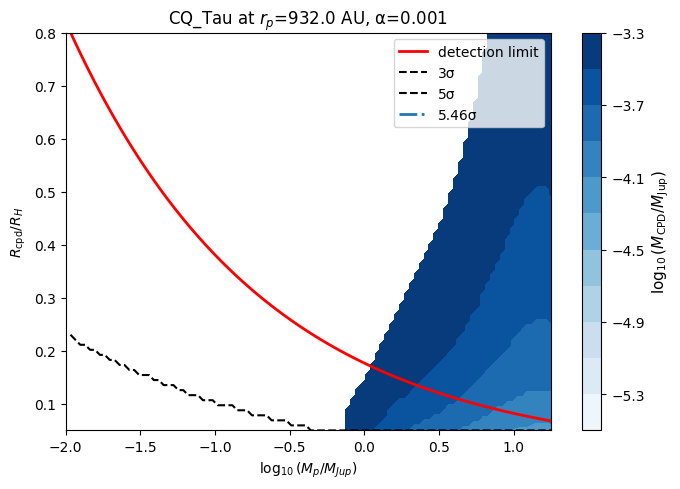

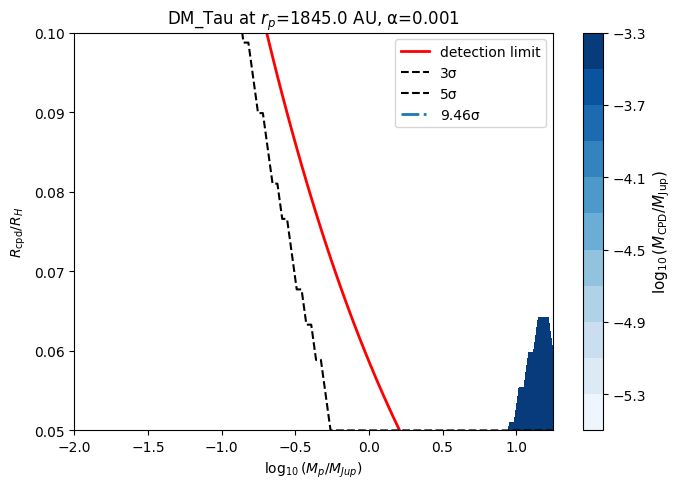

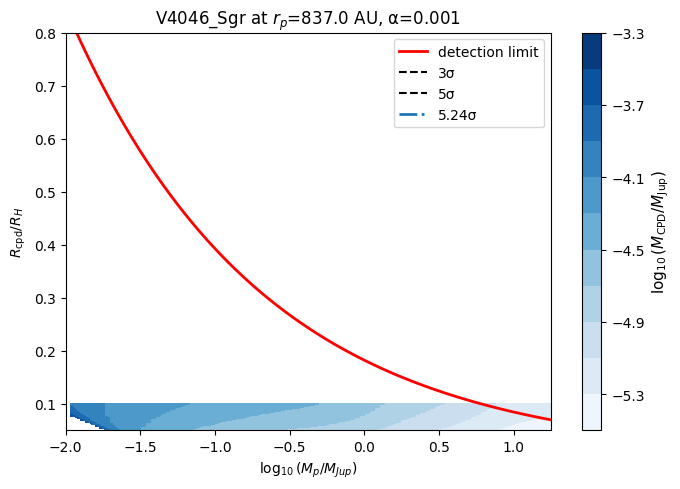

In [15]:
# plot all of the 5 sig source by loading the csv files

CQTau165 = pd.read_csv(os.path.join('Andrews', 'CQ_Tau_165.37_alpha0.001_5sigma.csv'))
CQTau932 = pd.read_csv(os.path.join('Andrews', 'CQ_Tau_932.14_alpha0.001_5sigma.csv'))
DMTau1845 = pd.read_csv(os.path.join('Andrews', 'DM_Tau_1845.47_alpha0.001_5sigma.csv'))
V4046Sgr837 = pd.read_csv(os.path.join('Andrews', 'V4046_Sgr_837.63_alpha0.001_5sigma.csv'))

plot_flux_map(
    CQTau165['Mp_grid'].unique(),
    CQTau165['Rout_frac_grid'].unique(),
    CQTau165.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    CQTau165.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['CQ_Tau'],
    rp=165.37,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2],
    sigma_ujy=five_sigma_sources[0][3],
    det_sigma=five_sigma_sources[0][5]
)

plot_flux_map(
    CQTau932['Mp_grid'].unique(),
    CQTau932['Rout_frac_grid'].unique(),
    CQTau932.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    CQTau932.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['CQ_Tau'],
    rp=932,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2],
    sigma_ujy=five_sigma_sources[1][3],
    det_sigma=five_sigma_sources[1][5]
)

plot_flux_map(
    DMTau1845['Mp_grid'].unique(),
    DMTau1845['Rout_frac_grid'].unique(),
    DMTau1845.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    DMTau1845.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['DM_Tau'],
    rp=1845,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.1,
    res_au=disk_arr['DM_Tau'][4]*disk_arr['DM_Tau'][2],
    sigma_ujy=five_sigma_sources[2][3],
    det_sigma=five_sigma_sources[2][5]

)


plot_flux_map(
    V4046Sgr837['Mp_grid'].unique(),
    V4046Sgr837['Rout_frac_grid'].unique(),
    V4046Sgr837.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    V4046Sgr837.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['V4046_Sgr'],
    rp=837,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['V4046_Sgr'][4]*disk_arr['V4046_Sgr'][2],
    sigma_ujy=five_sigma_sources[3][3],
    det_sigma=five_sigma_sources[3][5]
)



# Compute them one by one

For wide orbit, extreme condition maybe required. so they have to be dealt with one by one

### CQ Tau 165

Loading cached results from Andrews\CQ_Tau_165.37_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\CQ_Tau_165.37_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


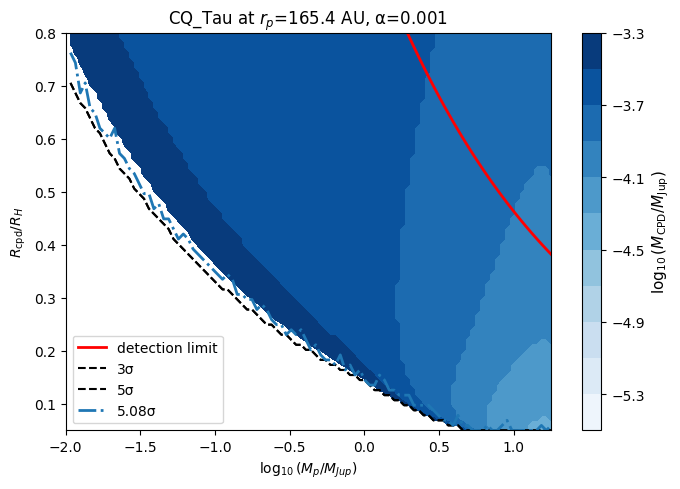

In [16]:
disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[0]
Mp_grid_CQTau165, Rout_frac_grid_CQTau165, Flux_vals_CQTau165, M_cpd_chosen_CQTau165 = compute_flux_map(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        y_min =0.05,
        y_max=0.8,
        inc=disk_arr[disk_name][5],
        mode ="5sigma",
        overwrite=False,
        n_jobs=-1
        )


plot_flux_map(
    Mp_grid_CQTau165,
    Rout_frac_grid_CQTau165,
    Flux_vals_CQTau165,
    M_cpd_chosen_CQTau165,
    disk_arr=disk_arr['CQ_Tau'],
    rp=165.37,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2],
    sigma_ujy=five_sigma_sources[0][3],
    det_sigma=five_sigma_sources[0][5]
)



### CQ Tau 932

Loading cached results from Andrews\CQ_Tau_932.14_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\CQ_Tau_932.14_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


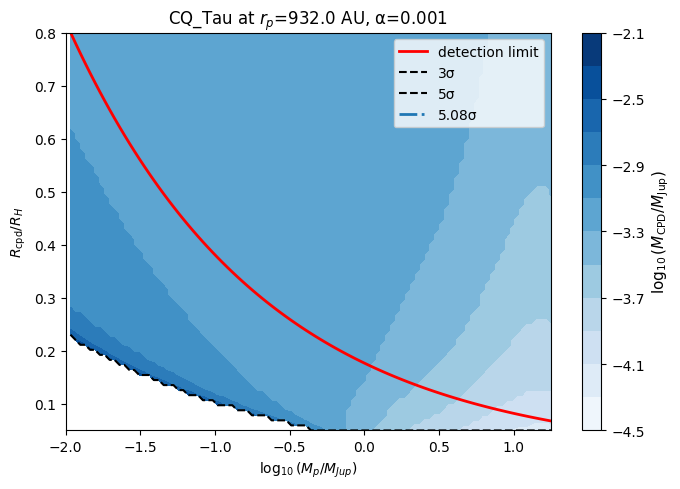

In [17]:
disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[1]
Mp_grid_CQTau932, Rout_frac_grid_CQTau932, Flux_vals_CQTau932, M_cpd_chosen_CQTau932 = compute_flux_map(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        y_min =0.05,
        y_max=0.8,
        mcpd_min = -4.5,
        mcpd_max = -2,
        inc=disk_arr[disk_name][5],
        mode ="5sigma",
        overwrite=False,
        n_jobs=8
        )


plot_flux_map(
    Mp_grid_CQTau932,
    Rout_frac_grid_CQTau932,
    Flux_vals_CQTau932,
    M_cpd_chosen_CQTau932,
    disk_arr=disk_arr['CQ_Tau'],
    rp=932,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2],
    sigma_ujy=five_sigma_sources[0][3],
    det_sigma=five_sigma_sources[0][5],
    min = -4.5,
    max = -2
)

### DM Tau 1845

Loading cached results from Andrews\DM_Tau_1845.47_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\DM_Tau_1845.47_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


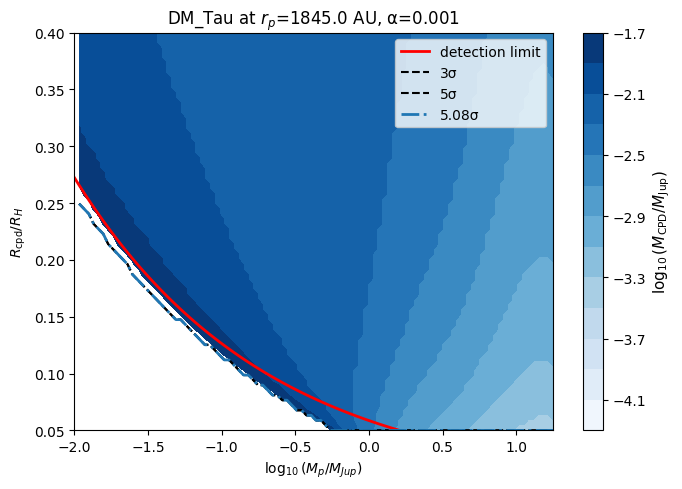

In [18]:
disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[2]
Mp_grid_DMTau1845, Rout_frac_grid_DMTau1845, Flux_vals_DMTau1845, M_cpd_chosen_DMTau1845 = compute_flux_map(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        y_min =0.05,
        y_max=0.4,
        mcpd_min = -4.3,
        mcpd_max = -1.5,
        inc=disk_arr[disk_name][5],
        mode ="5sigma",
        overwrite=False,
        n_jobs=8
        )


plot_flux_map(
    Mp_grid_DMTau1845,
    Rout_frac_grid_DMTau1845,
    Flux_vals_DMTau1845,
    M_cpd_chosen_DMTau1845,
    disk_arr=disk_arr['DM_Tau'],
    rp=1845,
    plotmass=True,
    y_min=0.05,
    y_max=0.4,
    res_au=disk_arr['DM_Tau'][4]*disk_arr['DM_Tau'][2],
    sigma_ujy=five_sigma_sources[0][3],
    det_sigma=five_sigma_sources[0][5],
    min = -4.3,
    max = -1.5
)

### V4046 Sgr 836


Loading cached results from Andrews\V4046_Sgr_837.63_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\V4046_Sgr_837.63_alpha0.001_5sigma.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


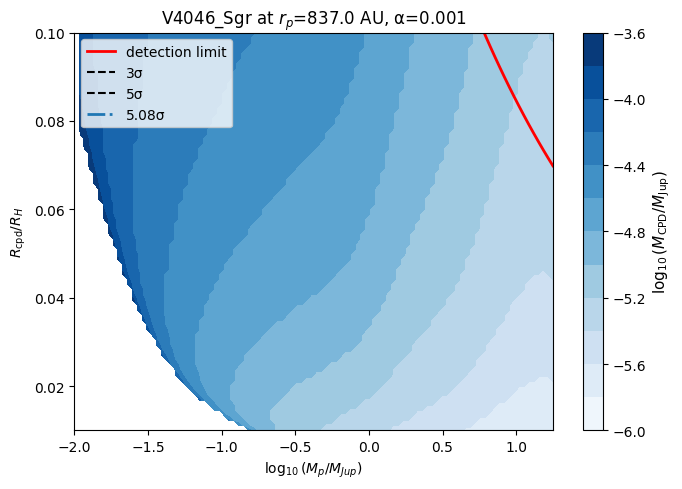

In [19]:
disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB, detection_sigma = five_sigma_sources[3]
Mp_grid_V4046Sgr846, Rout_frac_grid_V4046Sgr846, Flux_vals_V4046Sgr846, M_cpd_chosen_V4046Sgr846 = compute_flux_map(
        target_flux_arr=[sigma_flux_ujy*PB*detection_sigma],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        y_min =0.01,
        y_max=0.1,
        mcpd_min = -6,
        mcpd_max = -3.5,
        inc=disk_arr[disk_name][5],
        mode ="5sigma",
        overwrite=False,
        n_jobs=8
        )


plot_flux_map(
    Mp_grid_V4046Sgr846,
    Rout_frac_grid_V4046Sgr846,
    Flux_vals_V4046Sgr846,
    M_cpd_chosen_V4046Sgr846,
    disk_arr=disk_arr['V4046_Sgr'],
    rp=837,
    plotmass=True,
    y_min=0.01,
    y_max=0.1,
    res_au=disk_arr['V4046_Sgr'][4]*disk_arr['V4046_Sgr'][2],
    sigma_ujy=five_sigma_sources[0][3],
    det_sigma=five_sigma_sources[0][5],
    min = -6,
    max = -3.5
)

### Plot the 4 sources tgt with a common mass range

#### aim: streamline the plot and add the detection limit line 


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\181134057.py:32: RuntimeWarning: divide by zero encountered in log10
  np.log10(cfg["Mp_grid"]), cfg["Rout_frac_grid"], np.log10(cfg["M_cpd_chosen"]),


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\181134057.py:32: RuntimeWarning: divide by zero encountered in log10
  np.log10(cfg["Mp_grid"]), cfg["Rout_frac_grid"], np.log10(cfg["M_cpd_chosen"]),


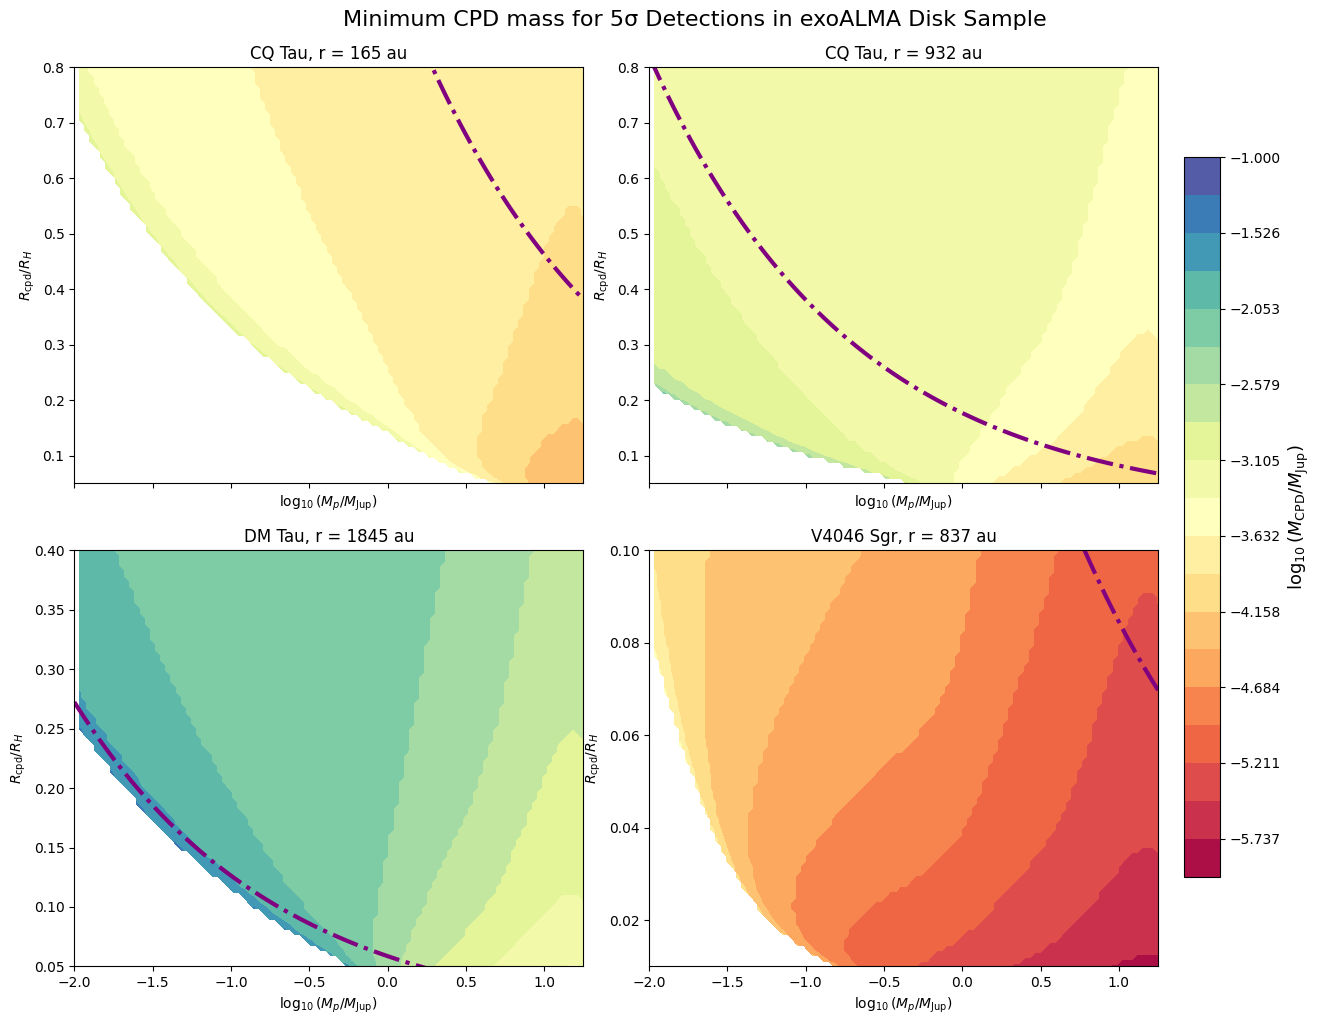

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Map source index to five_sigma_sources for rp lookup
source_configs = [
    {"idx": 0, "Mp_grid": Mp_grid_CQTau165, "Rout_frac_grid": Rout_frac_grid_CQTau165, 
     "M_cpd_chosen": M_cpd_chosen_CQTau165, "title": "CQ Tau, r = 165 au", "y_lim": (0.05, 0.8)},
    {"idx": 1, "Mp_grid": Mp_grid_CQTau932, "Rout_frac_grid": Rout_frac_grid_CQTau932, 
     "M_cpd_chosen": M_cpd_chosen_CQTau932, "title": "CQ Tau, r = 932 au", "y_lim": (0.05, 0.8)},
    {"idx": 2, "Mp_grid": Mp_grid_DMTau1845, "Rout_frac_grid": Rout_frac_grid_DMTau1845, 
     "M_cpd_chosen": M_cpd_chosen_DMTau1845, "title": "DM Tau, r = 1845 au", "y_lim": (0.05, 0.4)},
    {"idx": 3, "Mp_grid": Mp_grid_V4046Sgr846, "Rout_frac_grid": Rout_frac_grid_V4046Sgr846, 
     "M_cpd_chosen": M_cpd_chosen_V4046Sgr846, "title": "V4046 Sgr, r = 837 au", "y_lim": (0.01, 0.1)},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, cfg in enumerate(source_configs):
    # Extract disk parameters
    disk_name, _, _, _, beam_arcsec, _,_,_ = disk_arr[five_sigma_sources[cfg["idx"]][0]]
    rp = five_sigma_sources[cfg["idx"]][1]
    M_star_jup = disk_arr[five_sigma_sources[cfg["idx"]][0]][1] * 1047.56
    
    # Compute Hill radius and beam limit
    RHill_arr = rp * (cfg["Mp_grid"] / (3 * M_star_jup))**(1/3)
    res_au = beam_arcsec * disk_arr[five_sigma_sources[cfg["idx"]][0]][2]
    Rout_frac_beam = res_au / (2 * RHill_arr)
    
    # Plot contour
    cf = axes[i].contourf(
        np.log10(cfg["Mp_grid"]), cfg["Rout_frac_grid"], np.log10(cfg["M_cpd_chosen"]),
        levels=np.linspace(-6, -1, 20), cmap="Spectral"
    )
    axes[i].plot(np.log10(cfg["Mp_grid"]), Rout_frac_beam, color = 'purple', linestyle='-.', lw=3, label='detection limit')
    
    # Labels and limits
    axes[i].set_title(cfg["title"])
    axes[i].set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$")
    axes[i].set_ylabel(r"$R_{\rm cpd}/R_H$")
    axes[i].set_ylim(cfg["y_lim"])
    # axes[i].legend()

# Shared colorbar
fig.tight_layout()
cbar = fig.colorbar(cf, ax=axes, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)

plt.suptitle("Minimum CPD mass for 5σ Detections in exoALMA Disk Sample", fontsize=16, y=1.02)
plt.show()

Need to ask if sigma * peaek - detection is equivalent to the CASA integrated flux 
- add in caption all the fixed parameters.
- Add the detection limit, discuss the opacity and temperature dominance, the size of the Rout, 
So obviously , the mass for DM tau is too big,and resonable for V4046 Sgr, also a bit too large for the two CQ tau sources. Unless I raise the temperatature strucute by either adding a Tism , or some other heating .

For CQ tau more likely Mp ranges from 1 to 10 Mjup .  


# Planet Kink


In [21]:
# planet kink


for disk_name, radius_au, sigma_flux_ujy in kink_sources:
    compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        mode ="planet",
        overwrite=False
    )


Loading cached results from Andrews\AA_Tau_80_alpha0.001_planet.csv
Loading cached results from Andrews\SY_Cha_140_alpha0.001_planet.csv
Loading cached results from Andrews\J1842_105_alpha0.001_planet.csv
Loading cached results from Andrews\J1615_310_alpha0.001_planet.csv
Loading cached results from Andrews\LkCa_15_240_alpha0.001_planet.csv
Loading cached results from Andrews\HD_143006_32_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


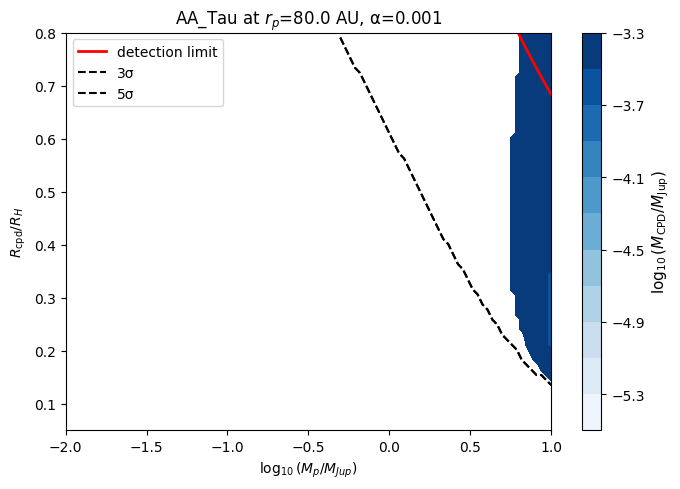

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


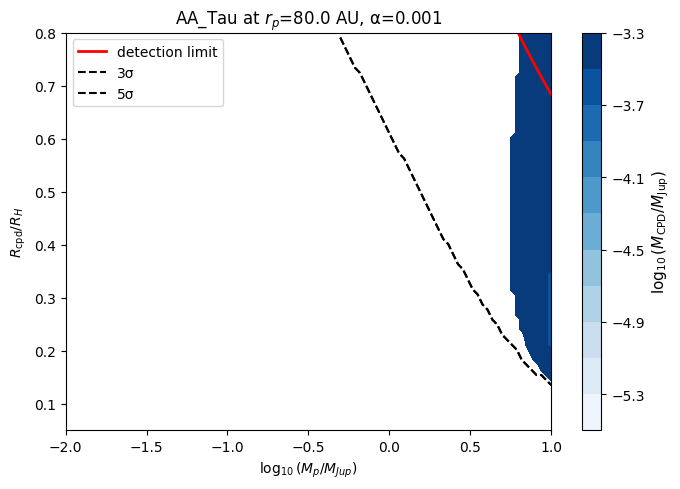

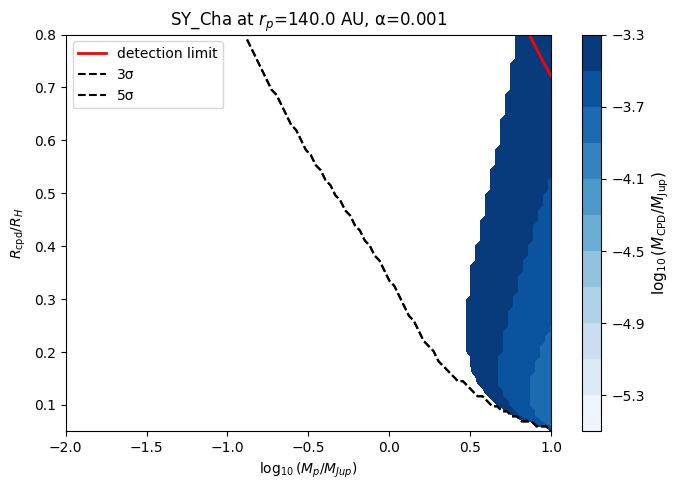

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


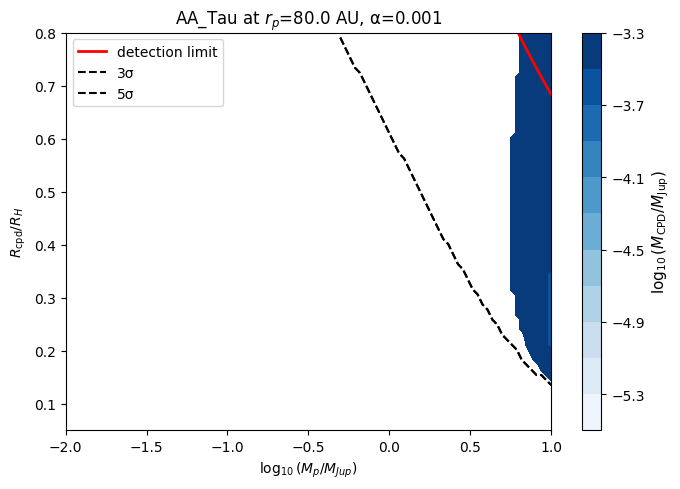

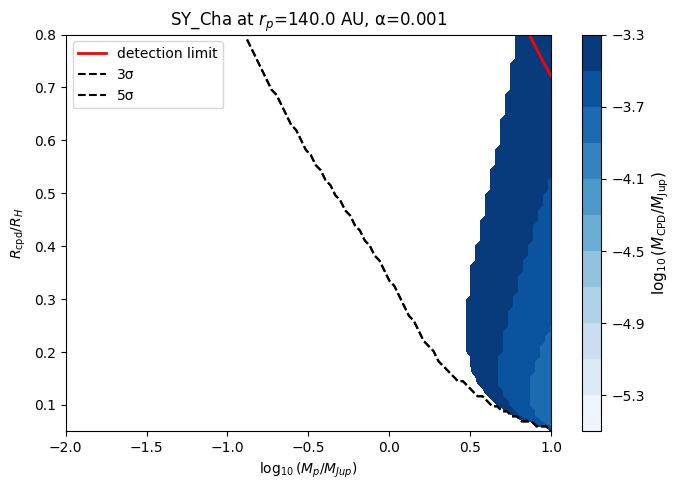

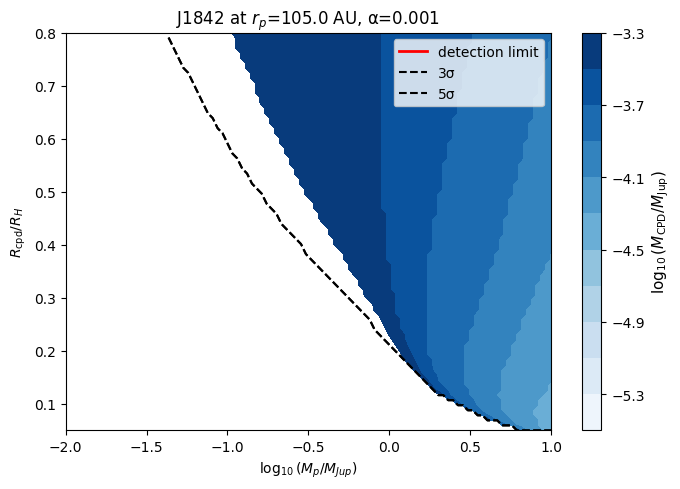

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


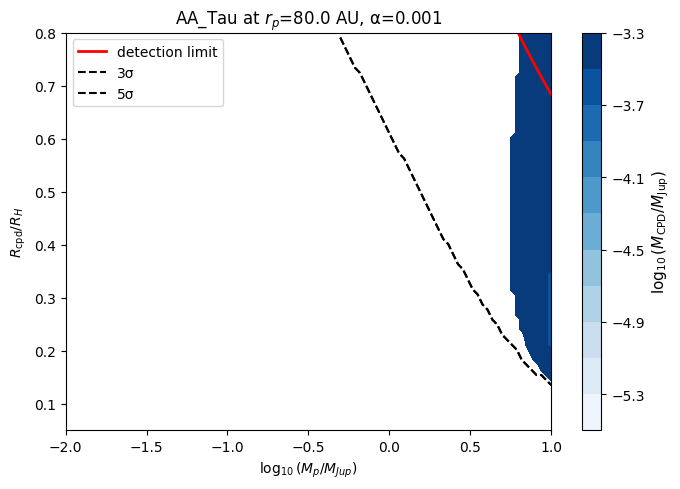

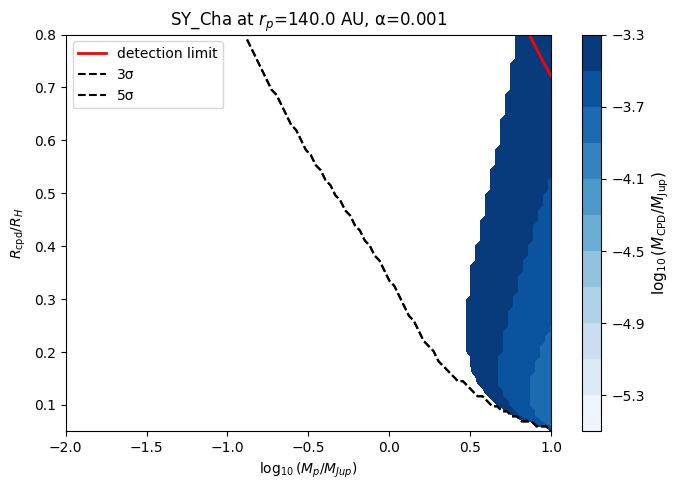

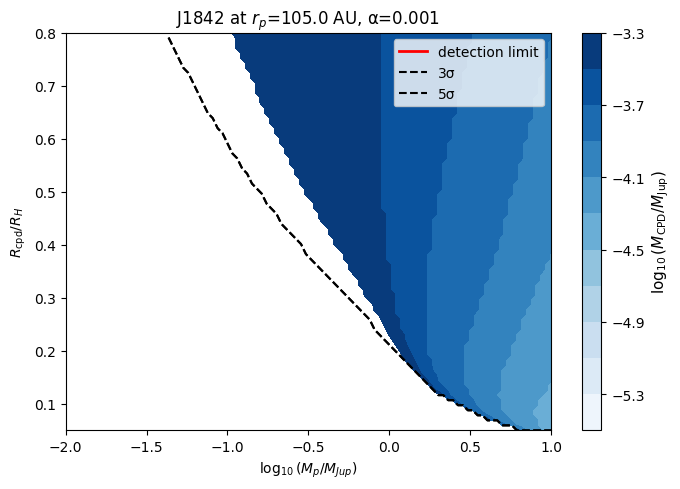

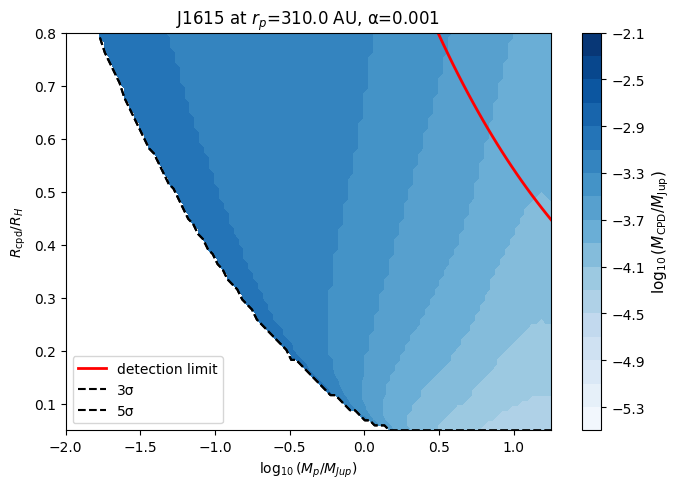

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


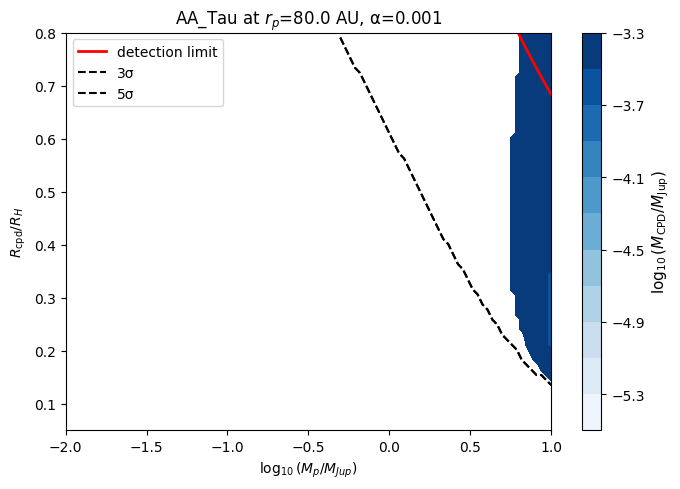

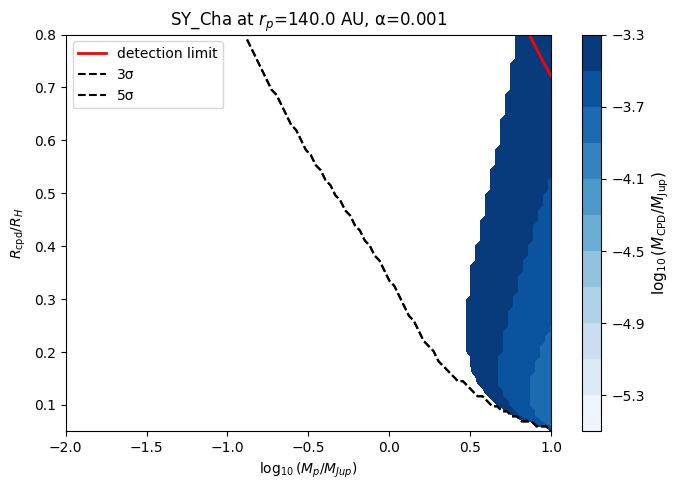

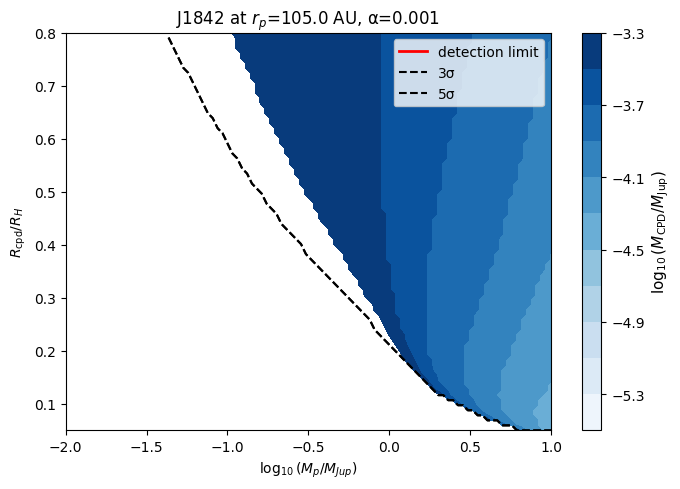

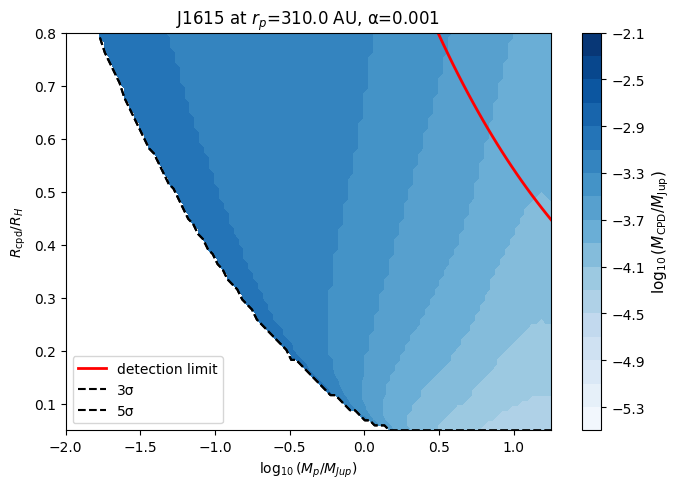

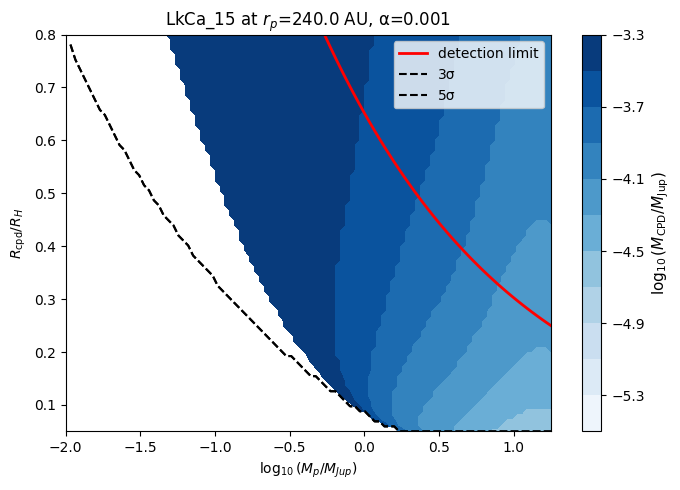

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


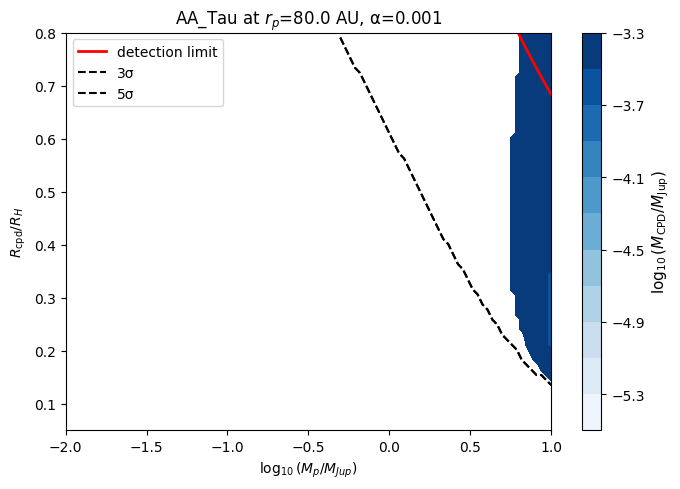

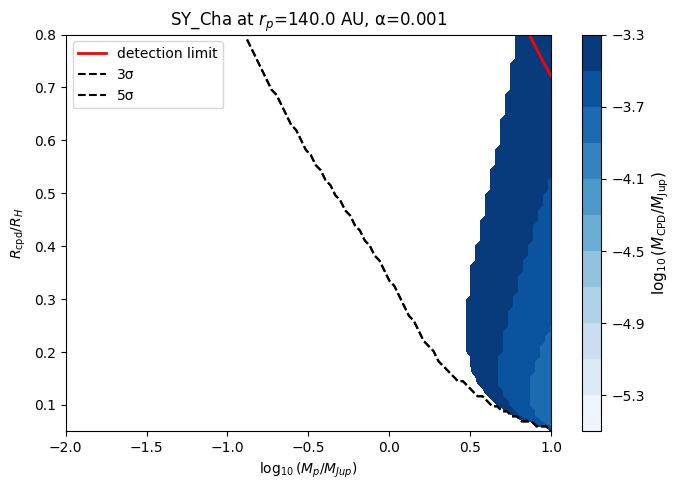

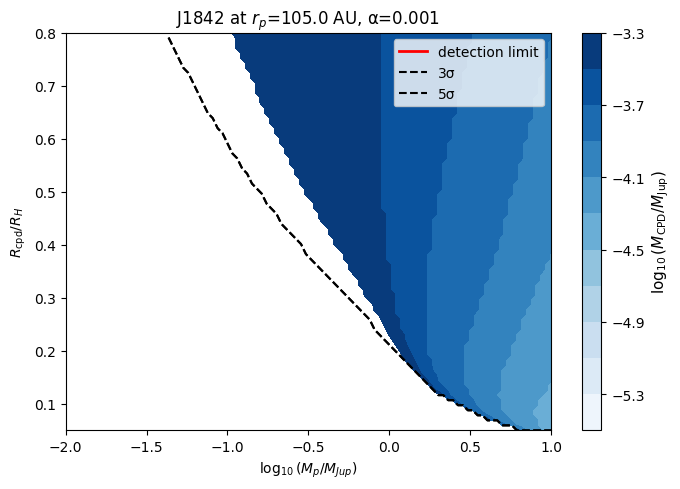

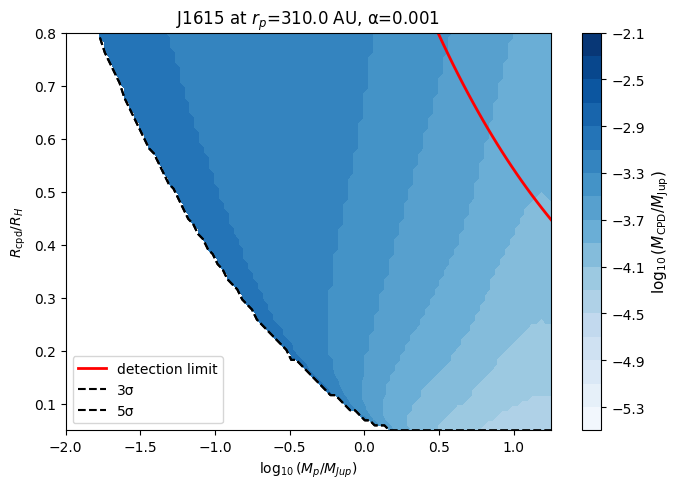

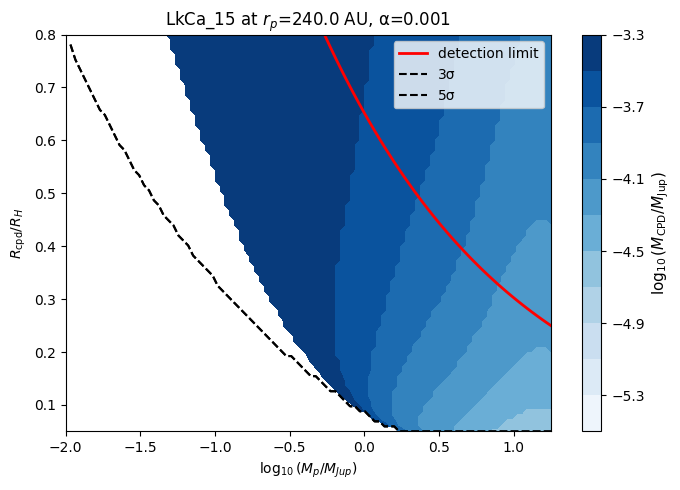

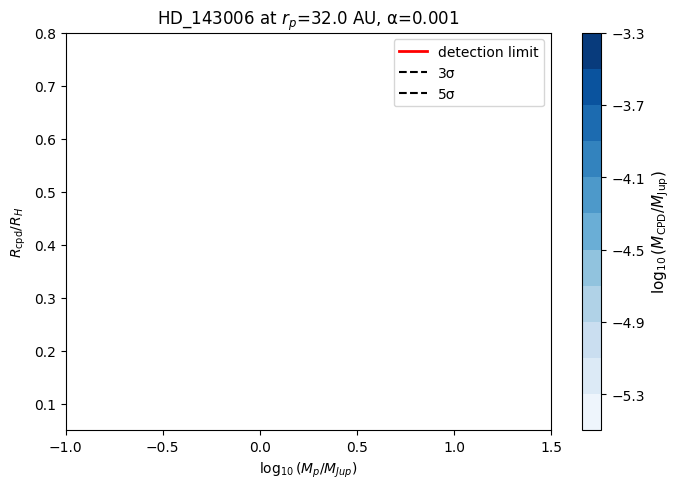

In [22]:
# plot all of the kink source by loading the csv files
AATau80 = pd.read_csv(os.path.join('Andrews', 'AA_Tau_80_alpha0.001_planet.csv'))
SYCha140 = pd.read_csv(os.path.join('Andrews', 'SY_Cha_140_alpha0.001_planet.csv'))
J1842105 = pd.read_csv(os.path.join('Andrews', 'J1842_105_alpha0.001_planet.csv'))
J1615310 = pd.read_csv(os.path.join('Andrews', 'J1615_310_alpha0.001_planet.csv'))
LkCa15240 = pd.read_csv(os.path.join('Andrews', 'LkCa_15_240_alpha0.001_planet.csv'))
HD14300632 = pd.read_csv(os.path.join('Andrews', 'HD_143006_32_alpha0.001_planet.csv'))

plot_flux_map(
    AATau80['Mp_grid'].unique(),
    AATau80['Rout_frac_grid'].unique(),
    AATau80.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    AATau80.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['AA_Tau'],
    rp=80,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['AA_Tau'][4]*disk_arr['AA_Tau'][2],
    sigma_ujy= kink_sources[0][2]
)

plot_flux_map(
    SYCha140['Mp_grid'].unique(),
    SYCha140['Rout_frac_grid'].unique(),
    SYCha140.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    SYCha140.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['SY_Cha'],
    rp=140,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['SY_Cha'][4]*disk_arr['SY_Cha'][2],
    sigma_ujy= kink_sources[1][2]
)
plot_flux_map(
    J1842105['Mp_grid'].unique(),
    J1842105['Rout_frac_grid'].unique(),
    J1842105.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    J1842105.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['J1842'],
    rp=105,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,  
    res_au=disk_arr['J1842'][4]*disk_arr['J1842'][2],
    sigma_ujy= kink_sources[2][2]
)   

plot_flux_map(
    J1615310['Mp_grid'].unique(),
    J1615310['Rout_frac_grid'].unique(),
    J1615310.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    J1615310.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['J1615'],
    rp=310,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['J1615'][4]*disk_arr['J1615'][2],
    sigma_ujy= kink_sources[3][2],
    min = -5.5,
    max = -2
)


plot_flux_map(
    LkCa15240['Mp_grid'].unique(),
    LkCa15240['Rout_frac_grid'].unique(),
    LkCa15240.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    LkCa15240.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['LkCa_15'],
    rp=240,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['LkCa_15'][4]*disk_arr['LkCa_15'][2],
    sigma_ujy= kink_sources[4][2]
)


plot_flux_map(
    HD14300632['Mp_grid'].unique(),
    HD14300632['Rout_frac_grid'].unique(),
    HD14300632.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    HD14300632.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['HD_143006'],
    rp=32,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['HD_143006'][4]*disk_arr['HD_143006'][2],
    sigma_ujy= kink_sources[5][2]
)




Loading cached results from Andrews\HD_143006_32_alpha0.001_planet.csv


Loading cached results from Andrews\HD_143006_32_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\HD_143006_32_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


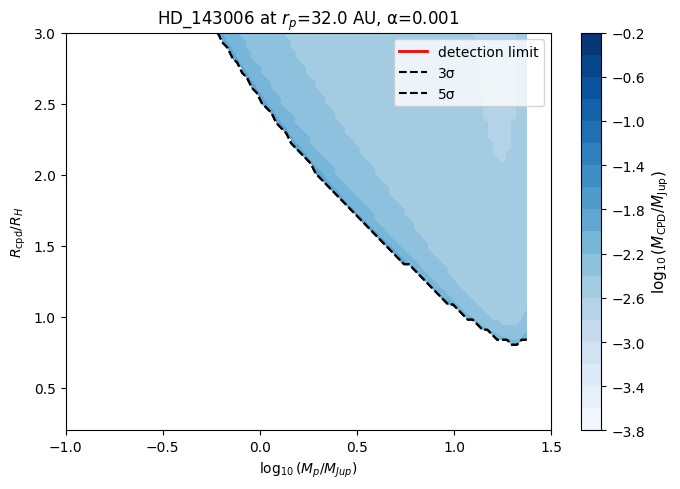

In [23]:
# only overwrite the HD_143006 commpute flux map and plot
# HD14300632 = pd.read_csv(os.path.join('Andrews', 'HD_143006_32_alpha0.001_planet.csv'))

disk_name, radius_au, sigma_flux_ujy = kink_sources[-1]

compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        m_min = -1,
        m_max = 1.5,
        y_min = 0.2,
        y_max = 3,
        mcpd_min = -3.8,
        mcpd_max = 0,
        mode ="planet",
        overwrite=False
    )

HD14300632 = pd.read_csv(os.path.join('Andrews', 'HD_143006_32_alpha0.001_planet.csv'))

plot_flux_map(
    HD14300632['Mp_grid'].unique(),
    HD14300632['Rout_frac_grid'].unique(),
    HD14300632.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    HD14300632.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['HD_143006'],
    rp=32,
    alpha=1e-3,
    plotmass=True,
    res_au=disk_arr['HD_143006'][4]*disk_arr['HD_143006'][2],
    sigma_ujy= kink_sources[5][2],
    y_min=0.2,
    y_max=3,
    min = -3.8,
    max = 0
    
)




Loading cached results from Andrews\AA_Tau_80_alpha0.001_planet.csv


Loading cached results from Andrews\AA_Tau_80_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\AA_Tau_80_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


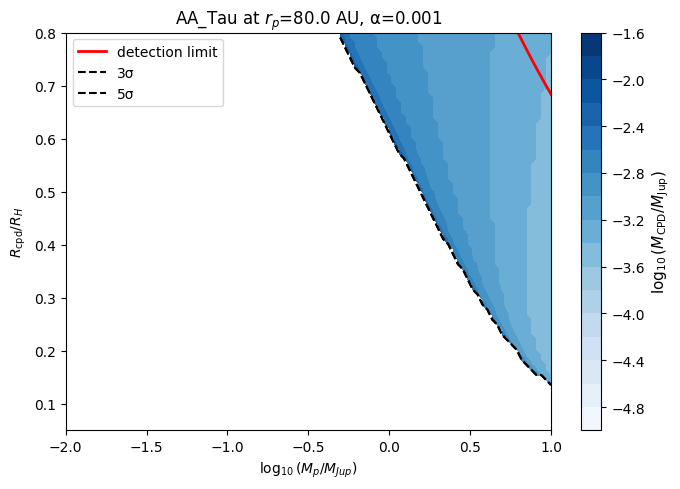

In [24]:
# overwrite for AATau at 80 au

disk_name, radius_au, sigma_flux_ujy = kink_sources[0]
compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        m_min = -2,
        m_max = 1,
        y_min = 0.05,
        y_max = 0.8,
        mcpd_min = -5,
        mcpd_max = -1.5,
        mode ="planet",
        overwrite=False
    )

AATau80 = pd.read_csv(os.path.join('Andrews', 'AA_Tau_80_alpha0.001_planet.csv'))

plot_flux_map(
    AATau80['Mp_grid'].unique(),
    AATau80['Rout_frac_grid'].unique(),
    AATau80.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    AATau80.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['AA_Tau'],
    rp=80,
    alpha=1e-3,
    plotmass=True,
    res_au=disk_arr['AA_Tau'][4]*disk_arr['AA_Tau'][2],
    sigma_ujy= kink_sources[0][2],
    y_min=0.05,
    y_max=0.8,
    min = -5,
    max = -1.5
)

Loading cached results from Andrews\SY_Cha_140_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\SY_Cha_140_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


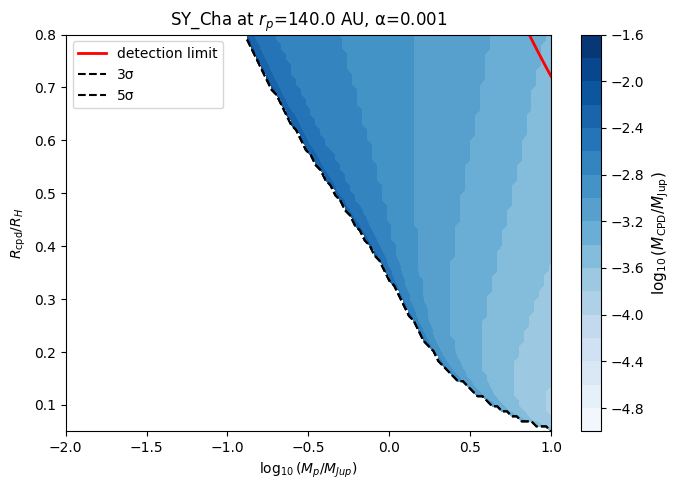

In [25]:
# for SYCha at 140 au
disk_name, radius_au, sigma_flux_ujy = kink_sources[1]
compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        m_min = -2,
        m_max = 1,
        y_min = 0.05,
        y_max = 0.8,
        mcpd_min = -5,
        mcpd_max = -1.5,
        mode ="planet",
        overwrite=False
    )
SYCha140 = pd.read_csv(os.path.join('Andrews', 'SY_Cha_140_alpha0.001_planet.csv'))

plot_flux_map(
    SYCha140['Mp_grid'].unique(),
    SYCha140['Rout_frac_grid'].unique(),
    SYCha140.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    SYCha140.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['SY_Cha'],
    rp=140,
    alpha=1e-3,
    plotmass=True,
    res_au=disk_arr['SY_Cha'][4]*disk_arr['SY_Cha'][2],
    sigma_ujy= kink_sources[1][2],
    y_min=0.05,
    y_max=0.8,
    min = -5,
    max = -1.5
)

Loading cached results from Andrews\J1842_105_alpha0.001_planet.csv


Loading cached results from Andrews\J1842_105_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


Loading cached results from Andrews\J1842_105_alpha0.001_planet.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\917936062.py:158: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


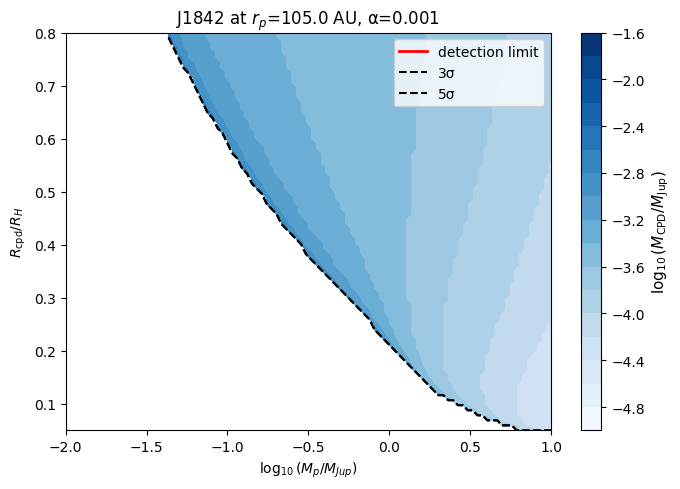

In [26]:
#  J1842 at 105 au
disk_name, radius_au, sigma_flux_ujy = kink_sources[2]
compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        m_min = -2,
        m_max = 1,
        y_min = 0.05,
        y_max = 0.8,
        mcpd_min = -5,
        mcpd_max = -1.5,
        mode ="planet",
        overwrite=False
    )
J1842105 = pd.read_csv(os.path.join('Andrews', 'J1842_105_alpha0.001_planet.csv'))
plot_flux_map(
    J1842105['Mp_grid'].unique(),
    J1842105['Rout_frac_grid'].unique(),
    J1842105.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    J1842105.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['J1842'],
    rp=105,
    alpha=1e-3,
    plotmass=True,
    res_au=disk_arr['J1842'][4]*disk_arr['J1842'][2],
    sigma_ujy= kink_sources[2][2],
    y_min=0.05,
    y_max=0.8,
    min = -5,
    max = -1.5
)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\1572000154.py:37: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\1572000154.py:37: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


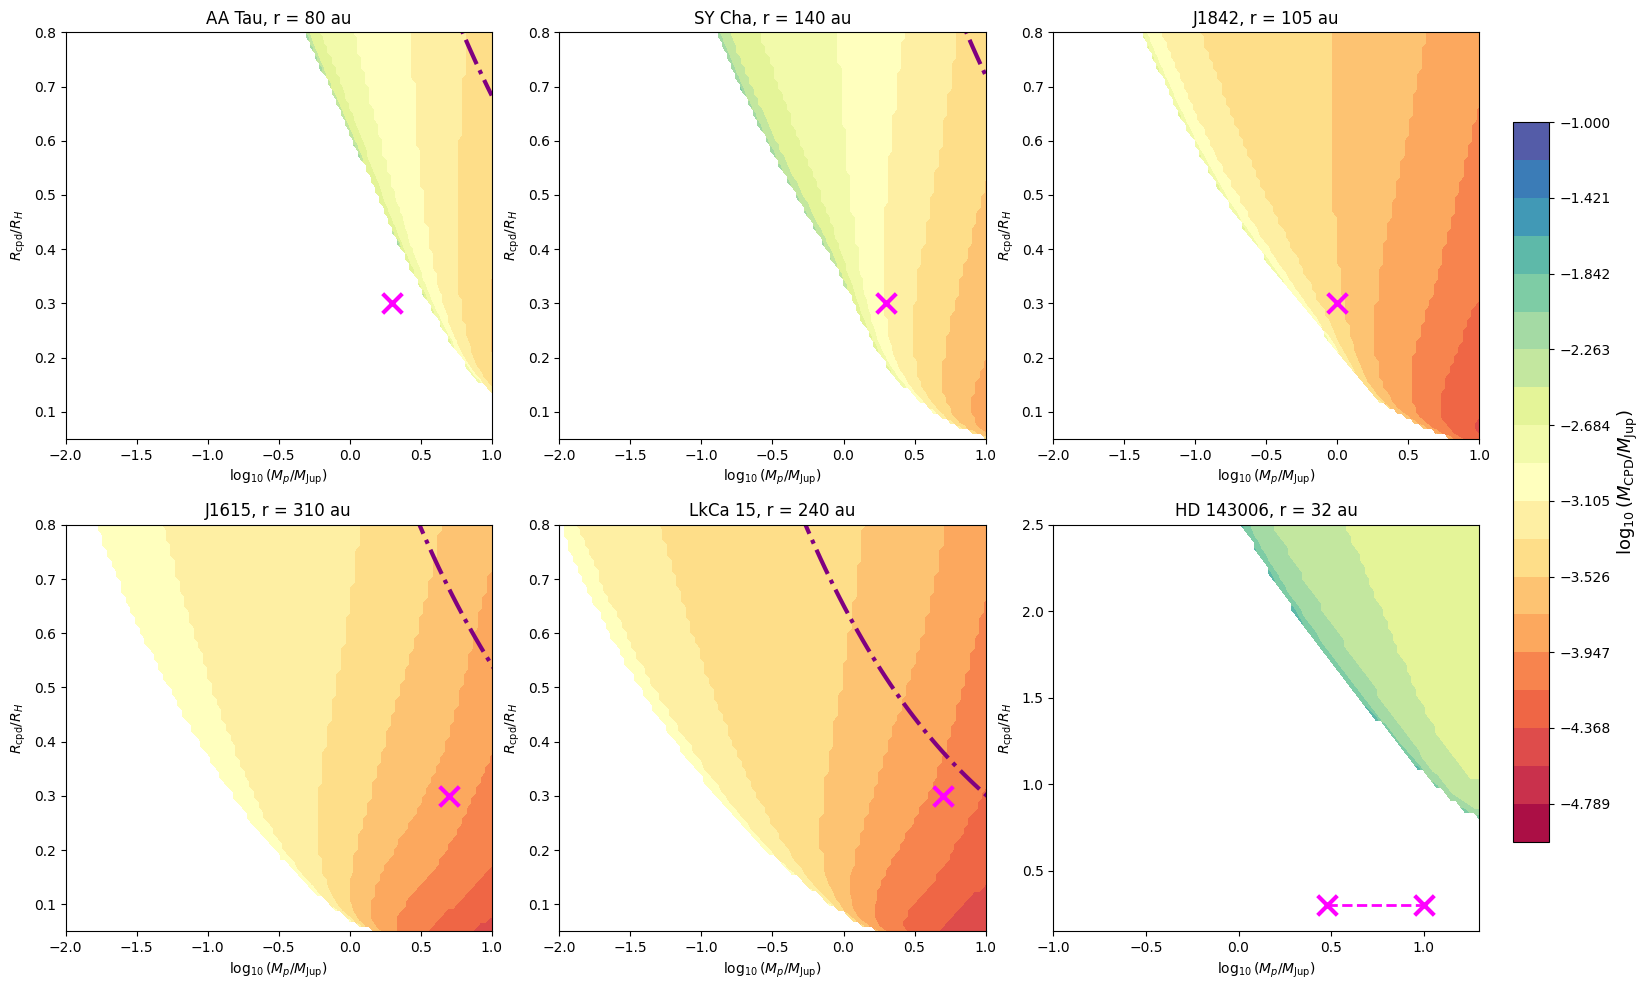

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Streamlined kink source configuration
# Ballabio, G. 2021 : get the modelled planet mass range , others are values from teh exoALMA paper 
kink_configs = [
    {"idx": 0, "df": AATau80, "disk_name": "AA_Tau", "title": "AA Tau, r = 80 au", "rp": 80, "y_lim": (0.05, 0.8), "x_lim": (-2, 1), "planet_mass": 2},
    {"idx": 1, "df": SYCha140, "disk_name": "SY_Cha", "title": "SY Cha, r = 140 au", "rp": 140, "y_lim": (0.05, 0.8), "x_lim": (-2, 1), "planet_mass": 2},
    {"idx": 2, "df": J1842105, "disk_name": "J1842", "title": "J1842, r = 105 au", "rp": 105, "y_lim": (0.05, 0.8), "x_lim": (-2, 1), "planet_mass": 1},
    {"idx": 3, "df": J1615310, "disk_name": "J1615", "title": "J1615, r = 310 au", "rp": 310, "y_lim": (0.05, 0.8), "x_lim": (-2, 1), "planet_mass": 5},
    {"idx": 4, "df": LkCa15240, "disk_name": "LkCa_15", "title": "LkCa 15, r = 240 au", "rp": 240, "y_lim": (0.05, 0.8), "x_lim": (-2, 1), "planet_mass": 5},
    {"idx": 5, "df": HD14300632, "disk_name": "HD_143006", "title": "HD 143006, r = 32 au", "rp": 32, "y_lim": (0.15, 2.5), "x_lim": (-1, 1.3), "planet_mass": [3,10]},
]



fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cfg in enumerate(kink_configs):
    # Extract data
    Mp_grid = cfg["df"]['Mp_grid'].unique()
    Rout_frac_grid = cfg["df"]['Rout_frac_grid'].unique()
    M_cpd_chosen = cfg["df"].pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values
    
    # Get disk parameters
    disk_params = disk_arr[cfg["disk_name"]]
    M_star_jup = disk_params[1] * 1047.56
    
    # Compute beam limit
    RHill_arr = cfg["rp"] * (Mp_grid / (3 * M_star_jup))**(1/3)
    res_au = disk_params[4] * disk_params[2]  # multiply PB by distance to get res in au
    Rout_frac_beam = res_au / (2 * RHill_arr)
    
    # Plot contour
    cf = axes[i].contourf(
        np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),
        levels=np.linspace(-5, -1, 20), cmap="Spectral"
    )
    axes[i].plot(np.log10(Mp_grid), Rout_frac_beam, color='purple', linestyle='-.', lw=3, label='detection limit')
    
    # Labels and limits
    axes[i].set_title(cfg["title"])
    axes[i].set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$")
    axes[i].set_ylabel(r"$R_{\rm cpd}/R_H$")
    axes[i].set_ylim(cfg["y_lim"])
    axes[i].set_xlim(cfg["x_lim"]) 
    planet_mass = cfg["planet_mass"]
    if isinstance(planet_mass, (list, tuple, np.ndarray)):
        # Plot two 'x' markers
        axes[i].scatter(np.log10(planet_mass), [0.3]*len(planet_mass), marker='x', color='magenta', s=200, linewidths=3, label='Planet')
        # Connect them with a horizontal dashed line
        axes[i].plot([np.log10(planet_mass[0]), np.log10(planet_mass[1])], [0.3, 0.3], color='magenta', linestyle='--', linewidth=2)
    else:
        axes[i].scatter(np.log10(planet_mass), 0.3, marker='x', color='magenta', s=200, linewidths=3, label='Planet')

# Shared colorbar
fig.tight_layout()
cbar = fig.colorbar(cf, ax=axes, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)


#plt.suptitle("Minimum Detectable CPD Mass at Kink Source Locations", fontsize=18)
plt.show()

In [28]:
# just run 

In [29]:
#  Plot for HD143006 D22 and D51 gaps with the exoALMA data 
# first define the new HD143005 disk array, with new beam size and noise at the sigma level 
# But that wouldnt tell me how deep we have gone further unless the CPD injection is done at that gap and found the same recovery fraction
# But I can get that first or can plot 3 sigma and 5sigam

#### HD143006 DSHARP And ExoALMA comparison

In [30]:
# HD_143006 at 22 AU: sigma = 506.74 μJy/beam
# HD_143006 at 51 AU: sigma = 1331.93 μJy/beam


HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8]


rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

Mp_D22_new, Rout_D22_new, Flux_D22_new, Mcpd_D22_new = compute_flux_map(
    target_flux_arr=[45],
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-3,
    lam_nu=331.6,
    overwrite=False,
    mode ="exoALMA",

)

Mp_D51_new, Rout_D51_new, Flux_D51_new, Mcpd_D51_new = compute_flux_map(
    target_flux_arr=[45],
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    alpha=1e-3,
    lam_nu=331.6,
    overwrite=False,
    mode ="exoALMA"
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Batch computation too fast (0.18044388240622225s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Batch computation too fast (0.03886556625366211s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Batch computation too fast (0.11074399948120117s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Batch computation too fast (0.11074399948120117s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done 148 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 148 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 236 tasks      | elapsed:    2.1s
[Parallel(

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Batch computation too fast (0.18044388240622225s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Batch computation too fast (0.03886556625366211s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Batch computation too fast (0.11074399948120117s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Batch computation too fast (0.11074399948120117s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done 148 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 148 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 236 tasks      | elapsed:    2.1s
[Parallel(

[INFO] Non-zero flux points: 3815/8000
Saved results to Andrews\HD143006_22_alpha0.001_exoALMA.csv
Loading cached results from Andrews\HD143006_51_alpha0.001_exoALMA.csv


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D22), Rout_D22, np.log10(Mcpd_D22),
C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:17: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D22_new), Rout_D22_new, np.log10(Mcpd_D22_new),
C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:25: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D51), Rout_D51, np.log10(Mcpd_D51),
C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:35: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D51_new), Rout_D51_new, np.log10(Mcpd_D51_new),


C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D22), Rout_D22, np.log10(Mcpd_D22),
C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:17: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D22_new), Rout_D22_new, np.log10(Mcpd_D22_new),
C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:25: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D51), Rout_D51, np.log10(Mcpd_D51),
C:\Users\LHEM\AppData\Local\Temp\ipykernel_9984\3150810336.py:35: RuntimeWarning: divide by zero encountered in log10
  np.log10(Mp_D51_new), Rout_D51_new, np.log10(Mcpd_D51_new),


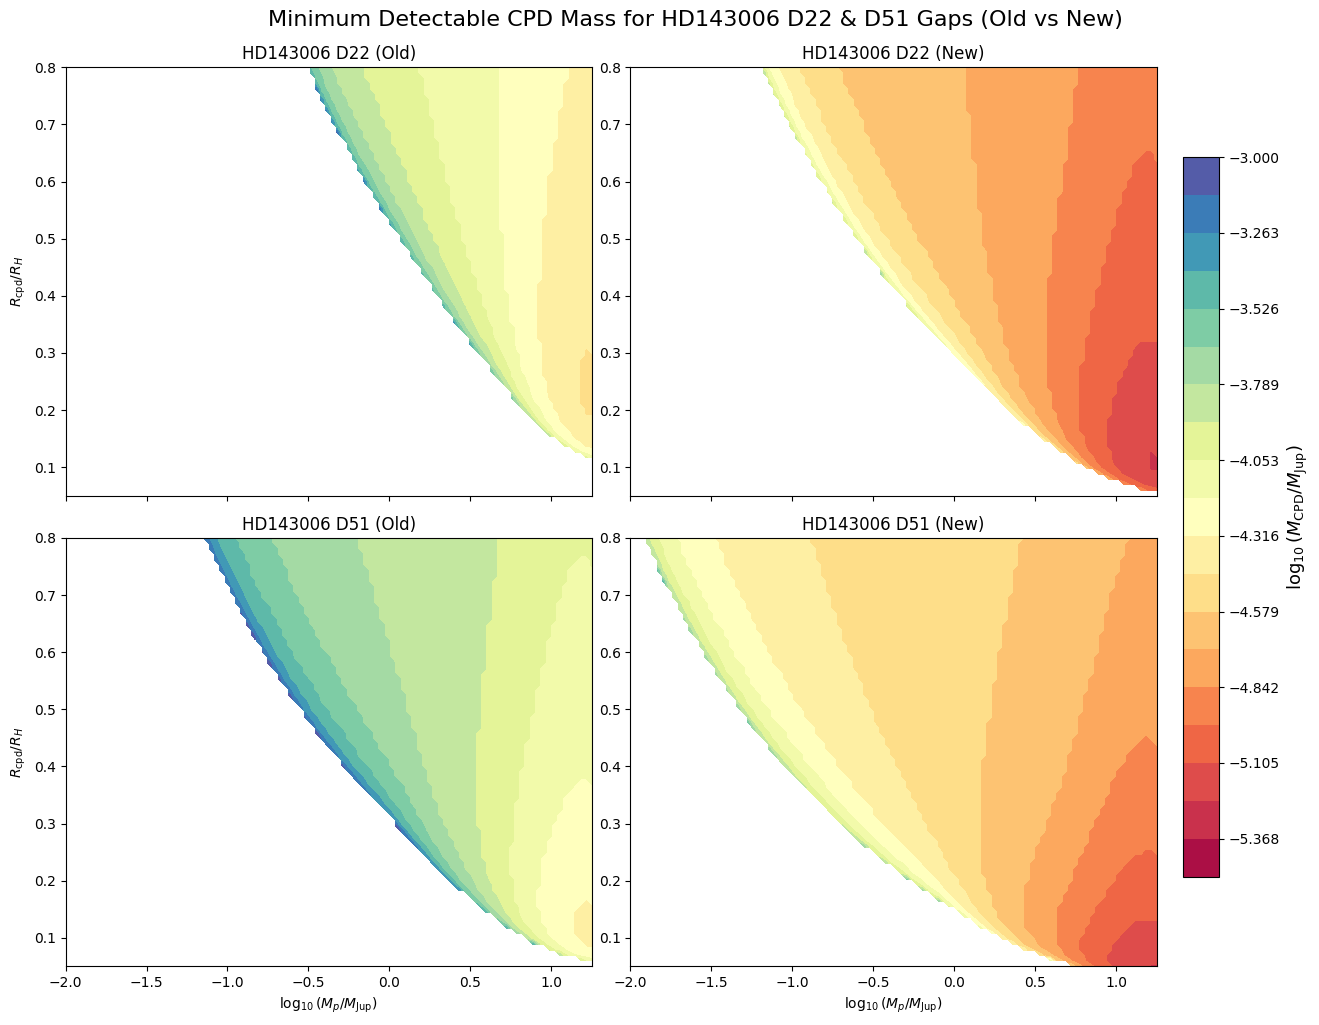

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# D22 old
cf1 = axes[0, 0].contourf(
    np.log10(Mp_D22), Rout_D22, np.log10(Mcpd_D22),
    levels=np.linspace(-5.5, -3, 20), cmap="Spectral"
)
axes[0, 0].set_title("HD143006 D22 (Old)")
axes[0, 0].set_ylabel(r"$R_{\rm cpd}/R_H$")
axes[0, 0].set_ylim(0.05, 0.8)

# D22 new
cf2 = axes[0, 1].contourf(
    np.log10(Mp_D22_new), Rout_D22_new, np.log10(Mcpd_D22_new),
    levels=np.linspace(-5.5, -3, 20), cmap="Spectral"
)
axes[0, 1].set_title("HD143006 D22 (New)")
axes[0, 1].set_ylim(0.05, 0.8)

# D51 old
cf3 = axes[1, 0].contourf(
    np.log10(Mp_D51), Rout_D51, np.log10(Mcpd_D51),
    levels=np.linspace(-5.5, -3, 20), cmap="Spectral"
)
axes[1, 0].set_title("HD143006 D51 (Old)")
axes[1, 0].set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$")
axes[1, 0].set_ylabel(r"$R_{\rm cpd}/R_H$")
axes[1, 0].set_ylim(0.05, 0.8)

# D51 new
cf4 = axes[1, 1].contourf(
    np.log10(Mp_D51_new), Rout_D51_new, np.log10(Mcpd_D51_new),
    levels=np.linspace(-5.5, -3, 20), cmap="Spectral"
)
axes[1, 1].set_title("HD143006 D51 (New)")
axes[1, 1].set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$")
axes[1, 1].set_ylim(0.05, 0.8)

fig.tight_layout()
cbar = fig.colorbar(cf4, ax=axes, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)
plt.suptitle("Minimum Detectable CPD Mass for HD143006 D22 & D51 Gaps (Old vs New)", fontsize=16, y=1.02)
plt.show()

technically, the plot should look the same as the mass calculated is wavelength independent ( should be) so thus any shift in the 

## Mass Limit Derivation for Gap regions


In [55]:
import pandas as pd

# Load the updated gap data with sigma
csv_path = r'd:\CPD_MPIA\Median_SNR\disk_object_files\gaps_with_sigma.csv'
gap_df = pd.read_csv(csv_path)

# Define disk name lists
strong_res_gaps_names = ["HD_143006", "HD_135344B", "MWC_758", "CQ_Tau", "HD_3842"]
mid_res_gaps_names = ["AA_Tau", "J1842", "V4046_Sgr", "DM_Tau"]
weak_res_gaps_names = ["SY_Cha",  "J1604", "J1852", "LkCa_15", "J1615"]

# Function to extract [disk_name, radius_au, sigma_uJy_per_beam] for a list of disk names

def get_gapinfo_list_from_df(disk_names, gap_df):
    result = []
    for name in disk_names:
        rows = gap_df[gap_df['disk_name'] == name]
        for _, row in rows.iterrows():
            result.append([row['disk_name'], row['radius_au'], row['sigma_uJy_per_beam']])
    return result

# Generate lists
strong_res_gaps = get_gapinfo_list_from_df(strong_res_gaps_names, gap_df)
mid_res_gaps = get_gapinfo_list_from_df(mid_res_gaps_names, gap_df)
weak_res_gaps = get_gapinfo_list_from_df(weak_res_gaps_names, gap_df)



In [56]:
# Pretty-print the gap lists for readability

def print_gap_list(label, gap_list):
    print(f"{label}:")
    for entry in gap_list:
        disk, radius, sigma = entry
        print(f"  {disk:12s} | radius = {radius:6.1f} AU | sigma = {sigma:10.2f} μJy/beam")
    print()

print_gap_list("Strong residual gaps", strong_res_gaps)
print_gap_list("Mid residual gaps", mid_res_gaps)
print_gap_list("Weak residual gaps", weak_res_gaps)


Strong residual gaps:
  HD_143006    | radius =   21.8 AU | sigma =     506.74 μJy/beam
  HD_143006    | radius =   52.2 AU | sigma =    1331.93 μJy/beam
  HD_135344B   | radius =   13.2 AU | sigma =     526.82 μJy/beam
  HD_135344B   | radius =   66.5 AU | sigma =   10429.01 μJy/beam
  MWC_758      | radius =   30.1 AU | sigma =    1807.47 μJy/beam
  MWC_758      | radius =   59.9 AU | sigma =    1838.53 μJy/beam

Mid residual gaps:
  AA_Tau       | radius =   11.0 AU | sigma =      72.51 μJy/beam
  AA_Tau       | radius =   64.3 AU | sigma =      71.62 μJy/beam
  AA_Tau       | radius =   79.8 AU | sigma =     136.85 μJy/beam
  AA_Tau       | radius =  105.3 AU | sigma =      90.19 μJy/beam
  J1842        | radius =   63.2 AU | sigma =     118.33 μJy/beam
  V4046_Sgr    | radius =    7.5 AU | sigma =      66.24 μJy/beam
  V4046_Sgr    | radius =   20.4 AU | sigma =     225.68 μJy/beam
  DM_Tau       | radius =   13.5 AU | sigma =     340.87 μJy/beam
  DM_Tau       | radius =   71.8 A

#### Strong Residual Disks

In [65]:
### Strong residual region


for disk_name, radius_au, sigma_flux_ujy in strong_res_gaps:
    compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        mode ="StrongRes",
        mcpd_max= 2,
        mcpd_min= -4,
        m_max = 1.5,
        y_min = 0.5,
        y_max = 4,
        overwrite=False
    )


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    7.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    7.6s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    7.7s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    7.7s
[Parallel(n_jobs=4)]: Batch computation too fast (0.19308234294886945s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    7.8s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08303189277648926s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  48 tasks      | elapsed:    7.9s
[Parallel(n_jobs=4)]: Batch computation too slow (2.1960494075347903s.) Setting batch_size=1.
[Parallel(n_jobs=4)]: Done  88 tasks      | elapsed:   11.5s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:   13.5s
[Parallel(n_jobs=4)]: Done 133 tasks      | elapsed:   14.3s
[Parallel(n_jobs=4)]: Batch computation too fast (0.19378449321729532s.) Setting batch_size=

[INFO] Non-zero flux points: 2598/8000
Saved results to Andrews\HD_143006_21.8_alpha0.001_StrongRes.csv


[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.1175544261932373s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Batch computation too fast (0.17696142196655273s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Batch computation too slow (2.4500369902702666s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done 632 tasks      | elapsed:    8.9s
[Parallel(n_jobs=4)]: Batch computation too fast (0.17333510948181158s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done 714 tasks      | elapsed:    9.2s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08618998527526855s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done 752 tasks      | elapsed:    9.3s
[Parallel(n_jobs=4)]: Batch computatio

[INFO] Non-zero flux points: 2893/8000
Saved results to Andrews\HD_143006_52.2_alpha0.001_StrongRes.csv


[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.07962369918823242s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.15753388404846191s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    1.0s
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 632 tasks      | elapsed:    2.3s
[Parallel(n_jobs=4)]: Done 840 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done 1048 tasks      | elapsed:    3.8s
[Parallel(n_jobs=4)]: Done 1288 tasks      | elapsed:    4.6s
[Parallel(n_jobs=4)]: Done 1528 tasks      | elapsed:    5.4s
[Parallel(n_jobs=4)]: Batch computation too slow (2.1346214296730404s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done 1758 tasks      | elapsed:   12.5s
[Parallel(n_jobs=4)]: Batch computation 

...

[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.1070101261138916s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Batch computation too fast (0.19979310035705566s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    2.2s
[Parallel(n_jobs=4)]: Batch computation too slow (2.0548653602600098s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    7.6s
[Parallel(n_jobs=4)]: Done 330 tasks      | elapsed:    7.8s
[Parallel(n_jobs=4)]: Batch computation too fast (0.18139599675415924s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done 352 tasks      | elapsed:    7.9s
[Parallel(n_jobs=4)]: Batch computation too fast (0.09961295127868652s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Batch computation too fast (0.16674590110778809s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 424 tasks      | elapsed:    8.2s
[Pa

[INFO] Non-zero flux points: 2305/8000
Saved results to Andrews\MWC_758_30.1_alpha0.001_StrongRes.csv


[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08891677856445312s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.1688401699066162s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    1.0s
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    1.7s
[Parallel(n_jobs=4)]: Done 632 tasks      | elapsed:    2.2s
[Parallel(n_jobs=4)]: Done 840 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Batch computation too slow (2.0818514529995955s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Batch computation too slow (3.0026705265045166s.) Setting batch_size=1.
[Parallel(n_jobs=4)]: Done 1006 tasks      | elapsed:    9.8s
[Parallel(n_jobs=4)]: Batch computation too fast (0.04340195655822754s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Batch computatio

[INFO] Non-zero flux points: 3578/8000
Saved results to Andrews\MWC_758_59.9_alpha0.001_StrongRes.csv


[Parallel(n_jobs=4)]: Done 8000 out of 8000 | elapsed:   33.1s finished


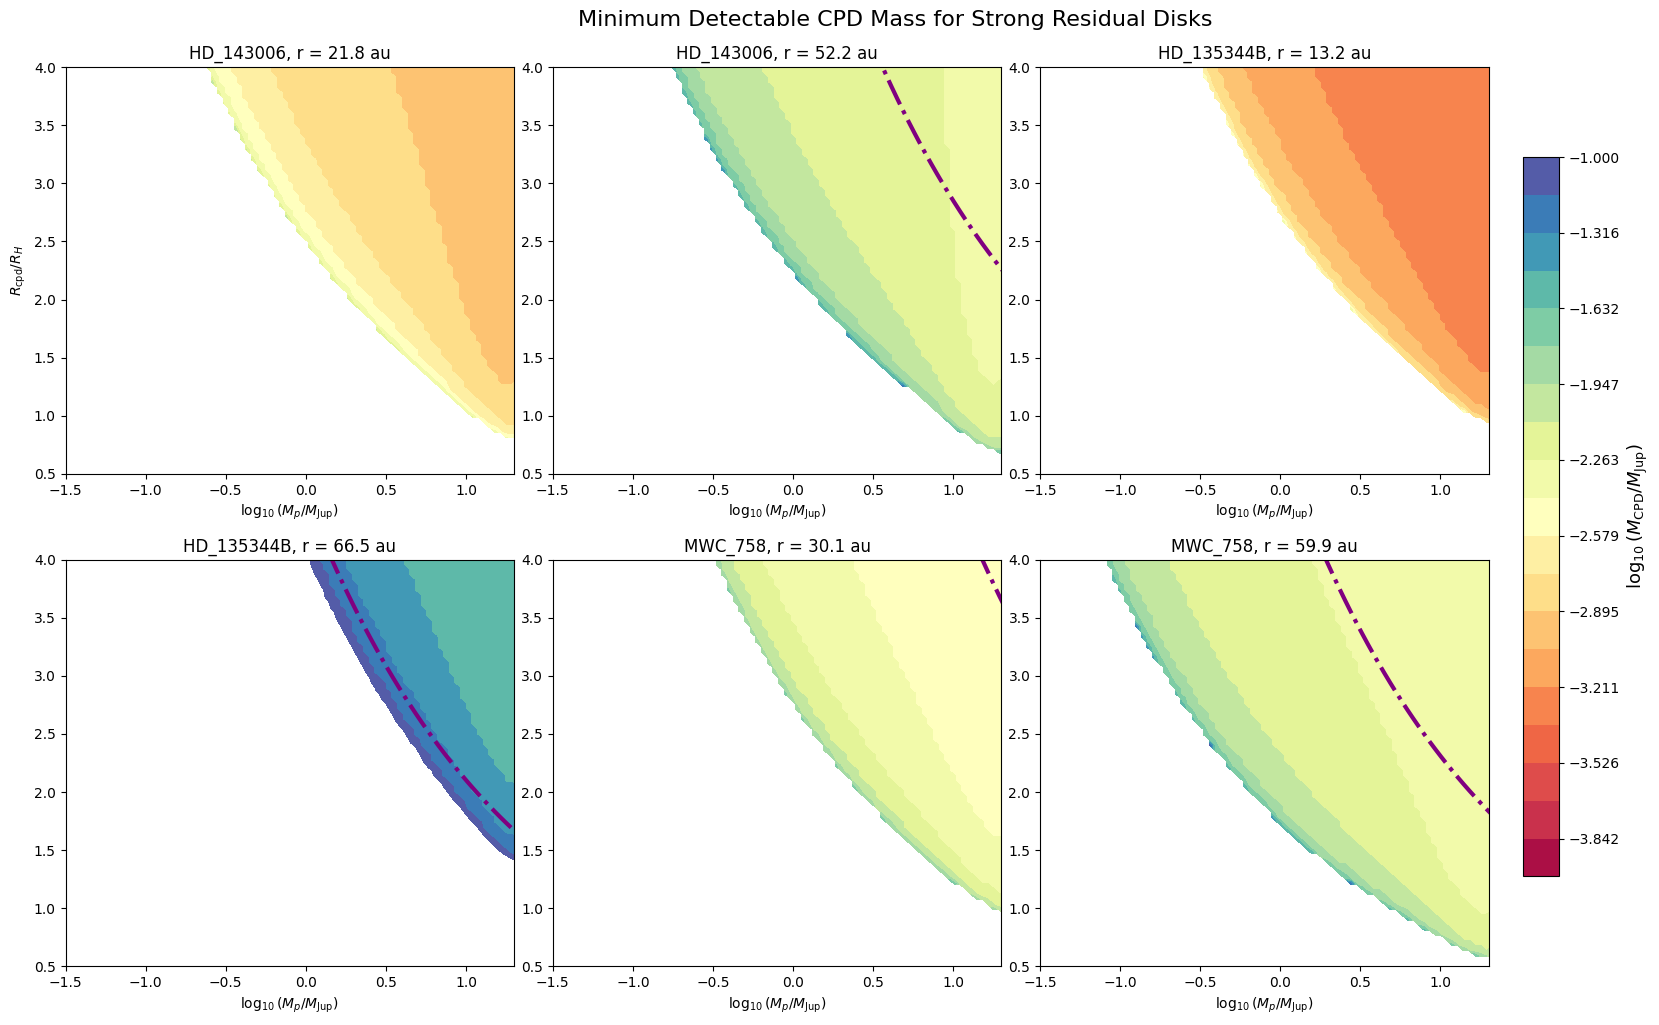

In [74]:
# Plot in a subplot



# Load all strong residual gap results
plot_configs = []
for disk_name, radius_au, sigma_flux_ujy in strong_res_gaps:
    fname = f"{disk_name}_{radius_au}_alpha0.001_StrongRes.csv"
    fpath = os.path.join("Andrews", fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        plot_configs.append({
            "disk_name": disk_name,
            "radius_au": radius_au,
            "sigma_flux_ujy": sigma_flux_ujy,
            "df": df,
            "title": f"{disk_name}, r = {radius_au:.1f} au",
            "y_lim": (0.5, 4)
        })

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cfg in enumerate(plot_configs):
    Mp_grid = cfg["df"]['Mp_grid'].unique()
    Rout_frac_grid = cfg["df"]['Rout_frac_grid'].unique()
    M_cpd_chosen = cfg["df"].pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values
    # Mask zeros to avoid log10 warnings
    M_cpd_chosen_plot = np.where(M_cpd_chosen > 0, M_cpd_chosen, np.nan)
    disk_params = disk_arr[cfg["disk_name"]]
    M_star_jup = disk_params[1] * 1047.56
    RHill_arr = cfg["radius_au"] * (Mp_grid / (3 * M_star_jup))**(1/3)
    res_au = disk_params[4] * disk_params[2]
    Rout_frac_beam = res_au / (2 * RHill_arr)
    cf = axes[i].contourf(
        np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen_plot),
        levels=np.linspace(-4, -1, 20), cmap="Spectral"
    )
    axes[i].plot(np.log10(Mp_grid), Rout_frac_beam, color='purple', linestyle='-.', lw=3, label='detection limit')
    axes[i].set_title(cfg["title"])
    axes[i].set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$")
    axes[i].set_ylim(cfg["y_lim"])
    axes[i].set_xlim(-1.5,1.3)
    if i == 0:
        axes[i].set_ylabel(r"$R_{\rm cpd}/R_H$")

fig.tight_layout()
cbar = fig.colorbar(cf, ax=axes, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)
plt.suptitle("Minimum Detectable CPD Mass for Strong Residual Disks", fontsize=16, y=1.02)
plt.show()


Add remark that no CPD at size 0.3 Rh can be observed. 

### Mid residual Region

In [75]:

for disk_name, radius_au, sigma_flux_ujy in mid_res_gaps:
    compute_flux_map(
        target_flux_arr=[5*sigma_flux_ujy],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        alpha=1e-3,
        inc=disk_arr[disk_name][5],
        mode ="MidRes",
        mcpd_max= -2,
        mcpd_min= -6,
        m_max = 1.5,
        y_min = 0.01,
        y_max = 1.5,
        overwrite=False
    )


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Batch computation too fast (0.189658605059577s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Batch computation too fast (0.04128718376159668s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    1.6s
[Parallel(n_jobs=4)]: Batch computation too fast (0.0739448070526123s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    1.7s
[Parallel(n_jobs=4)]: Batch computation too fast (0.15991997718811035s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 156 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done 332 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done 540 tasks      | elapsed:    3.4

[INFO] Non-zero flux points: 1210/8000
Saved results to Andrews\AA_Tau_11.0_alpha0.001_MidRes.csv


[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08999419212341309s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.16457343101501465s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Batch computation too slow (2.3837411453804602s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    8.3s
[Parallel(n_jobs=4)]: Done 562 tasks      | elapsed:    8.7s
[Parallel(n_jobs=4)]: Batch computation too fast (0.18711139353942877s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done 604 tasks      | elapsed:    8.8s
[Parallel(n_jobs=4)]: Batch computation too fast (0.06995677947998047s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Batch computation too fast (0.16284584999084473s.) Setting batch_size=16.
[P

[INFO] Non-zero flux points: 3887/8000
Saved results to Andrews\AA_Tau_64.3_alpha0.001_MidRes.csv


[Parallel(n_jobs=4)]: Batch computation too fast (0.047621965408325195s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08510541915893555s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Batch computation too fast (0.16468000411987305s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 632 tasks      | elapsed:    2.3s
[Parallel(n_jobs=4)]: Done 840 tasks      | elapsed:    6.1s
[Parallel(n_jobs=4)]: Batch computation too slow (2.1582214919627773s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done 1006 tasks      | elapsed:   10.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.18224301291174322

...

[Parallel(n_jobs=4)]: Batch computation too fast (0.03739619255065918s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.07859182357788086s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.16599702835083008s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    1.0s
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    1.6s
[Parallel(n_jobs=4)]: Done 632 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done 840 tasks      | elapsed:    2.7s
[Parallel(n_jobs=4)]: Done 1048 tasks      | elapsed:    3.3s
[Parallel(n_jobs=4)]: Done 1288 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Done 1528 tasks      | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done 1800 tasks   

[INFO] Non-zero flux points: 4621/8000
Saved results to Andrews\DM_Tau_71.8_alpha0.001_MidRes.csv


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Batch computation too fast (0.016632795333862305s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.03906536102294922s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.07921886444091797s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Batch computation too fast (0.15513348579406738s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:    0.9s
[Parallel(n_jobs=4)]: Done 456 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done 632 tasks      | elapsed:    2.0s
[Parallel(n_jobs=4)]: Done 840 tasks      | elapsed:   

[INFO] Non-zero flux points: 5632/8000
Saved results to Andrews\DM_Tau_102.5_alpha0.001_MidRes.csv


[Parallel(n_jobs=4)]: Done 7937 tasks      | elapsed:   33.8s
[Parallel(n_jobs=4)]: Done 8000 out of 8000 | elapsed:   33.9s finished


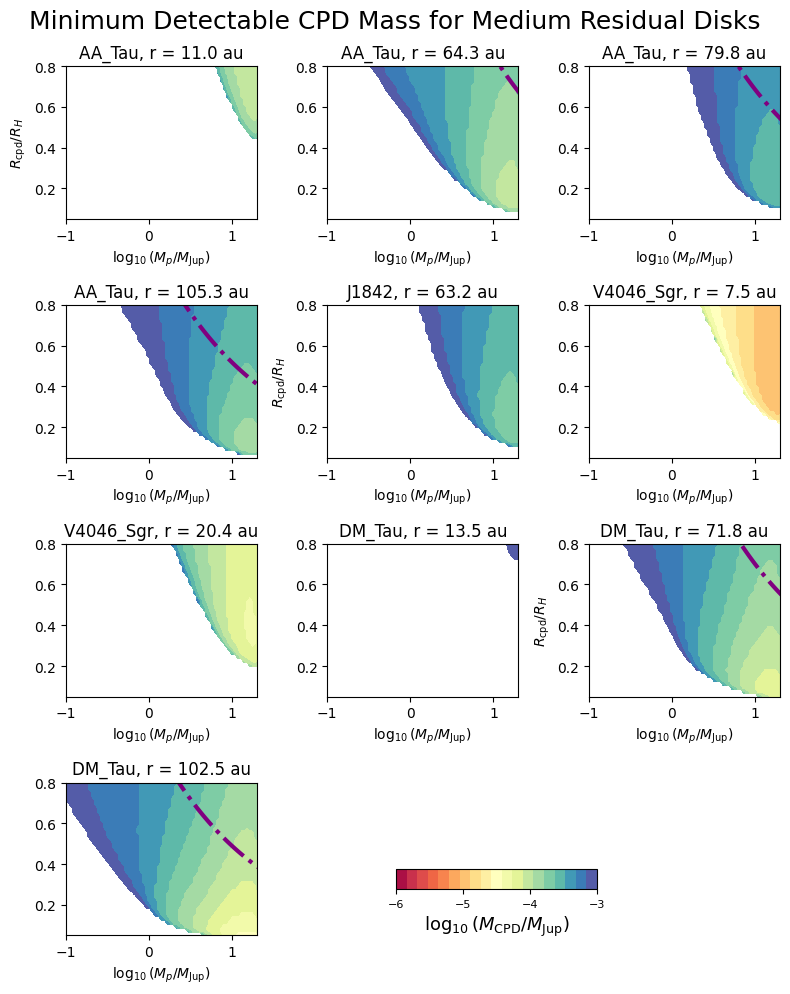

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Load all strong residual gap results
plot_configs = []
for disk_name, radius_au, sigma_flux_ujy in mid_res_gaps:
    fname = f"{disk_name}_{radius_au}_alpha0.001_MidRes.csv"
    fpath = os.path.join("Andrews", fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        plot_configs.append({
            "disk_name": disk_name,
            "radius_au": radius_au,
            "sigma_flux_ujy": sigma_flux_ujy,
            "df": df,
            "title": f"{disk_name}, r = {radius_au:.1f} au",
            "y_lim": (0.05, 0.8)
        })

fig, axes = plt.subplots(4, 3, figsize=(8, 10))
axes = axes.flatten()
nplots = min(len(plot_configs), 10)  # 10 plots, last 2 for colorbar

for i in range(12):
    if i < nplots:
        cfg = plot_configs[i]
        Mp_grid = cfg["df"]['Mp_grid'].unique()
        Rout_frac_grid = cfg["df"]['Rout_frac_grid'].unique()
        M_cpd_chosen = cfg["df"].pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values
        M_cpd_chosen_plot = np.where(M_cpd_chosen > 0, M_cpd_chosen, np.nan)
        disk_params = disk_arr[cfg["disk_name"]]
        M_star_jup = disk_params[1] * 1047.56
        RHill_arr = cfg["radius_au"] * (Mp_grid / (3 * M_star_jup))**(1/3)
        res_au = disk_params[4] * disk_params[2]
        Rout_frac_beam = res_au / (2 * RHill_arr)
        cf = axes[i].contourf(
            np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen_plot),
            levels=np.linspace(-6, -3, 20), cmap="Spectral"
        )
        axes[i].plot(np.log10(Mp_grid), Rout_frac_beam, color='purple', linestyle='-.', lw=3, label='detection limit')
        axes[i].set_title(cfg["title"])
        axes[i].set_xlabel(r"$\log_{10}(M_p/M_{\rm Jup})$")
        axes[i].set_ylim(cfg["y_lim"])
        axes[i].set_xlim(-1, 1.3)
        if i % 4 == 0:
            axes[i].set_ylabel(r"$R_{\rm cpd}/R_H$")
    else:
        axes[i].axis('off')

# Place horizontal colorbar in axes[10] (second to last)

# Place horizontal colorbar between axes[10] and axes[11]
# Get positions of axes[10] and axes[11]

# Get positions of axes[10] and axes[11]
pos10 = axes[10].get_position()
pos11 = axes[11].get_position()
x0 = pos10.x0
x1 = pos11.x1
y0 = pos10.y0

# Create a new axis for the colorbar
cbar_ax = fig.add_axes([(x1-x0), y0 , (x1 - x0)/2, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=13)
cbar.ax.tick_params(labelsize=8)
tick_locs = np.linspace(cf.levels.min(), cf.levels.max(), 4)
cbar.set_ticks(tick_locs)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Minimum Detectable CPD Mass for Medium Residual Disks", fontsize=18, y=0.99)
plt.show()